# DL Project 1 - Analysis of Premier League Values
## Alex Merino
### Due: 10/29/2024


## Background/Problem

The Premier League is England's top soccer/football league and is internationally watched and loved. This is true because it is one of, if not the best, leagues in the world. And to reach that status, the games need to be entertaining, and for the games to be entertaining, you need the best players in the world on every team. 

So long story short (or long correlation short), the players playing in the Premier League, make the league great, which intuitively makes sense, but going through the process allows us to get into the context of where our problem lies. 

In the Premier League, and soccer leagues everywhere, the main way to get a new player is to buy that player from another team or wait for the player to finish their contract and pick them up for free. The amount of money a team pays to buy another team’s player is called a **transfer value**, since that numerical value is how much the team paid for the transfer of the player. That transfer value is essentially an agreed upon term between the buying and selling team for how much that player is worth. Now keeping that in mind…

A **market value** for a player is the value that player would be worth if the player market was a **free market**. And a free market is an economic term which means that the price of something is determined by the supply and demand of buyers and sellers without any intervention. The definition of a market value does sound similar to transfer values, but with transfer values there are soccer federation standards that must be upheld with the spending and acquiring of money. The market value of a player and the potential transfer value of the player, more times than not will be different. The transfer value, however, is highly affected by the market value.

Now that we know what a **market value** is, we should look into how a market value is created. We collected the market value data from the website [TransferMarkt]( https://www.transfermarkt.com). TransferMarkt is the most widely recognized and accepted group which creates market values. The process of creating a market value is just as scientific as fine tuning a neural network (which is not every scientific at all). The market values are created by the soccer community, with a group consensus, not by any mathematical models or anything of the sort. Which does make the integrity of the data seem weak because this can introduce biases to the values.

##### MOST IMPORTANT FACTORS
- Future prospects
- Age
- Performance at the club and national team
- Level and status of the league, both in sporting and financial terms
- Reputation/prestige
- Development potential
- League-specific features
- Marketing value
- Number & reputation of interested clubs
- Performance potential
- Experience level
- Injury susceptibility
- Different financial conditions of clubs and leagues
- General demand and "trends" on the market
- General development of transfer fees
- External factors such as the coronavirus pandemic and its consequences

The list above is from the TransferMarkt website, which tells us what factors of a player are used by the community to create the market value. Many of these values however are not numerical or categorical, but based on opinions/biases. Reputation, future prospects, marketing value (commercials), injury susceptibility, development potential. None of these (other than injury susceptibility) affect how a player will play throughout a season. Yes, they could improve throughout the season, but that will reflect in the stats of the player. This brings us to the crux of the problem…

##### market values are inherently biased

So how do we get rid of these biases?

My solution to the problem is to give the statistics of a player to a machine, which is completely unbiased and has no concept of “future prospects” or “reputation” and run fully connected dense neural networks over the data.

## Data

For the data, I am using the full season statistics of players in the Premier League from the 2017/18 season to the 2023/24 season. Each player has a minimum of 113 unique statistics from the season. Goalkeepers, however, have 140 statistics since they have a lot more unique statistics that are tracked, which all other positions do not have. The statistics include goals, minutes played, passes, expected goals, throw ins, essentially every numerical statistic that exists. 

The output we are trying to predict is their expected market value based on the stats, which will be in millions of Euros. (10 = 10 million Euros)

The data will be split into train, validation, and test sets, with 5 seasons (2017/18 – 2021/22) going into train, 2022/23 will consist of validation, and 2023/24 will be the test set. 

Earlier, I mentioned that the market values were biased, and the goal was to strip away those biases from the value. But I am training my neural networks on these biased values. Here I will excuse the biases and trust that the community did a well enough job to properly evaluate the players, which does seem like the case more times than not. This is also why my training data is also the oldest seasons, so that the models are not affected by the most recent biased values. We want to keep the most recent season unknown to the model so we can see in current time, which players are being under/over valued based on their market value. 

The Forwards, Midfielders, and Defenders datasets will have 113 inputs, while the Goalkeepers and Full dataset will have 140 inputs. In the full dataset, the forwards, midfielders, and defenders will be zero padded to fit 140 input features.

## Setting up data for Models

In [1]:
import glob, torch, csv, os, time
from torch import nn, optim, save
from torchsummary import summary
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# Grab paths for data
trainpaths = glob.glob("data/train/*")
valpaths = glob.glob("data/val/*")
testpaths = glob.glob("data/test/*")
trainingList = []
valList = []
testingList = []

for path in trainpaths:
    with open(path, "r") as file:
        readFile = csv.reader(file, delimiter=",")  # Csv reader
        next(readFile)
        for row in readFile:
            # Read important data from file
            row = row[2:]
            trainingList.append(row)
    
for path in valpaths:
    with open(path, "r") as file:
        readFile = csv.reader(file, delimiter=",")
        next(readFile)
        for row in readFile:
            row = row[2:]
            valList.append(row)

for path in testpaths:                                
    with open(path, "r") as file:
        readFile = csv.reader(file, delimiter=",")
        next(readFile)
        for row in readFile:
            row = row[2:]
            testingList.append(row)  

In [3]:
# Create a custom Torch Dataset
class PlayerDataset(torch.utils.data.Dataset):
    def __init__(self, data, target):
        self.data = data
        self.target = target
        
    def __getitem__ (self, index):
        return self.data[index], torch.tensor(self.target[index]).type(torch.FloatTensor)
    
    def __len__(self):
        return len(self.data)
    
# Create a custom dataset for Test, so analysis can be run on players
class TestDataset(torch.utils.data.Dataset):
    def __init__(self, data, target, names):
        self.data = data
        self.target = target
        self.names = names
        
    def __getitem__ (self, index):
        return torch.tensor(self.data[index]), torch.tensor(self.target[index]).type(torch.FloatTensor), self.names[index]
    
    def __len__(self):
        return len(self.data)

Below is a huge block of code, but each subblock is doing the same exact thing. Since there are four different positions and the full dataset to test, I need to create 5 sets of training/validation/test data, hence the long block. The steps being taken in these subblocks are:

1. Drop all positions that are not used in respective dataset
2. Drop the Name of the player (train/val only)
3. Grab the given market values of the dataset as a List type
4. Take the rest of the dataset and store it as a numpy array.
5. Put the data into the custom dataset
6. Create a DataLoader Object (train/val only)

In [4]:
trdf = pd.DataFrame.from_dict(trainingList).drop([1,3], axis=1)
vdf = pd.DataFrame.from_dict(valList).drop([1,3], axis=1)
tedf = pd.DataFrame.from_dict(testingList).drop([1,3], axis=1)

train_full = trdf.drop([2], axis=1)
train_full_target = train_full[144].astype("float32").to_list()
train_full = train_full.iloc[:, 1:141].to_numpy().astype("float32")

train_full = PlayerDataset(train_full, train_full_target)
trainload_full = torch.utils.data.DataLoader(train_full)


train_gk = trdf[trdf[2] == "GK"].drop([2], axis=1)
train_gk_target = train_gk[144].astype("float32").to_list()
train_gk = train_gk.iloc[:, 1:141].to_numpy().astype("float32")

train_gk = PlayerDataset(train_gk, train_gk_target)
trainload_gk = torch.utils.data.DataLoader(train_gk)


train_fw = trdf[trdf[2] == "FW"].drop([2], axis=1)
train_fw_target = train_fw[144].astype("float32").to_list()
train_fw = train_fw.iloc[:, 1:114].to_numpy().astype("float32")

train_fw = PlayerDataset(train_fw, train_fw_target)
trainload_fw = torch.utils.data.DataLoader(train_fw)


train_mf = trdf[trdf[2] == "MF"].drop([2], axis=1)
train_mf_target = train_mf[144].astype("float32").to_list()
train_mf = train_mf.iloc[:, 1:114].to_numpy().astype("float32")

train_mf = PlayerDataset(train_mf, train_mf_target)
trainload_mf = torch.utils.data.DataLoader(train_mf)


train_df = trdf[trdf[2] == "DF"].drop([2], axis=1)
train_df_target = train_df[144].astype("float32").to_list()
train_df = train_df.iloc[:, 1:114].to_numpy().astype("float32")

train_df = PlayerDataset(train_df, train_df_target)
trainload_df = torch.utils.data.DataLoader(train_df)



val_full = vdf.drop([2], axis=1)
val_full_target = val_full[144].astype("float32").to_list()
val_full = val_full.iloc[:, 1:141].to_numpy().astype("float32")

val_full = PlayerDataset(val_full, val_full_target)
valload_full = torch.utils.data.DataLoader(val_full)


val_gk = vdf[vdf[2] == "GK"].drop([2], axis=1)
val_gk_target = val_gk[144].astype("float32").to_list()
val_gk = val_gk.iloc[:, 1:141].to_numpy().astype("float32")

val_gk = PlayerDataset(val_gk, val_gk_target)
valload_gk = torch.utils.data.DataLoader(val_gk)


val_fw = vdf[vdf[2] == "FW"].drop([2], axis=1)
val_fw_target = val_fw[144].astype("float32").to_list()
val_fw = val_fw.iloc[:, 1:114].to_numpy().astype("float32")

val_fw = PlayerDataset(val_fw, val_fw_target)
valload_fw = torch.utils.data.DataLoader(val_fw)


val_mf = vdf[vdf[2] == "MF"].drop([2], axis=1)
val_mf_target = val_mf[144].astype("float32").to_list()
val_mf = val_mf.iloc[:, 1:114].to_numpy().astype("float32")

val_mf = PlayerDataset(val_mf, val_mf_target)
valload_mf = torch.utils.data.DataLoader(val_mf)


val_df = vdf[vdf[2] == "DF"].drop([2], axis=1)
val_df_target = val_df[144].astype("float32").to_list()
val_df = val_df.iloc[:, 1:114].to_numpy().astype("float32")

val_df = PlayerDataset(val_df, val_df_target)
valload_df = torch.utils.data.DataLoader(val_df)




test_full = tedf.drop([2], axis=1)
test_full_target = test_full[144].astype("float32").to_list()
test_full_names = test_full.iloc[:, 0]
test_full = test_full.iloc[:, 1:141].to_numpy().astype("float32")

test_full = TestDataset(test_full, test_full_target, test_full_names)


test_gk = tedf[tedf[2] == "GK"].drop([2], axis=1).reset_index(drop=True)
test_gk_target = test_gk[144].astype("float32").to_list()
test_gk_names = test_gk.iloc[:, 0]
test_gk = test_gk.iloc[:, 1:141].to_numpy().astype("float32")

test_gk = TestDataset(test_gk, test_gk_target, test_gk_names)


test_fw = tedf[tedf[2] == "FW"].drop([2], axis=1).reset_index(drop=True)
test_fw_target = test_fw[144].astype("float32").to_list()
test_fw_names = test_fw.iloc[:, 0]
test_fw = test_fw.iloc[:, 1:114].to_numpy().astype("float32")

test_fw = TestDataset(test_fw, test_fw_target, test_fw_names)


test_mf = tedf[tedf[2] == "MF"].drop([2], axis=1).reset_index(drop=True)
test_mf_target = test_mf[144].astype("float32").to_list()
test_mf_names = test_mf.iloc[:, 0]
test_mf = test_mf.iloc[:, 1:114].to_numpy().astype("float32")

test_mf = TestDataset(test_mf, test_mf_target, test_mf_names)


test_df = tedf[tedf[2] == "DF"].drop([2], axis=1).reset_index(drop=True)
test_df_target = test_df[144].astype("float32").to_list()
test_df_names = test_df.iloc[:, 0]
test_df = test_df.iloc[:, 1:114].to_numpy().astype("float32")

test_df = TestDataset(test_df, test_df_target, test_df_names)


In [22]:
#Train
def training(model, loader, opt, crit):
    model.train()
    # instantiate variables
    train_loss = 0
    correct1 = 0
    correct5 = 0
    total = 0
    for inputs, labels in loader:
        # Basic DL training structure
        inputs = inputs.view(inputs.size(0), -1)
        opt.zero_grad()
        outputs = model(inputs)
        
        loss = crit(outputs, labels)
        loss.backward()
        opt.step()
        
         # Track loss and accuracy
        train_loss += loss.item()

        # If within 1 it is considered correct
        if outputs >= labels - 1 and outputs <= labels + 1:
            correct1 += 1
        # If within 5 it is considered correct
        if outputs >= labels - 5 and outputs <= labels + 5:
            correct5 += 1        
        total += 1
        
    avg_loss = train_loss / len(loader)
    accuracy1 = correct1 / total
    accuracy5 = correct5 / total
    return avg_loss, accuracy1, accuracy5

# Validation function is exaclt same as training except is done with no back prop and so on
def validate(model, loader, crit):
    model.eval()
    val_loss = 0
    correct1 = 0
    correct5 = 0
    total = 0
    with torch.no_grad():
        for data, target in loader:
            data = data.view(data.size(0), -1)
            outputs = model(data)
            
            # Calculate loss
            loss = crit(outputs, target)
            val_loss += loss.item()
            if outputs >= target - 1 and outputs <= target + 1:
                correct1 += 1   
            if outputs >= target - 5 and outputs <= target + 5:
                correct5 += 1    
            total += 1
    
    avg_loss = val_loss / len(loader)
    accuracy1 = correct1 / total
    acc5 = correct5 / total
    return avg_loss, accuracy1, acc5

In [23]:
def looper(model, opt, crit, num_epochs, trainload, valload, tbestest, vbestest, tpath, vpath):

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    
    early = 0  
    pat = 21  # Patience of 21 epochs
    last = 0
    tbest = 0  # training best loss
    vbest = 0  # validation best loss
    
    for epoch in range(num_epochs):
        s = time.perf_counter()
        # Train and validate model
        tloss, train_accuracy,tac5 = training(model, trainload, opt, crit)
        vloss, val_accuracy, vac5 = validate(model, valload, crit)

        train_losses.append(tloss)
        val_losses.append(vloss)
        train_accuracies.append(tac5)
        val_accuracies.append(vac5)

        # If first epoch then update best vars
        if epoch == 0:
            tbest = tloss
            vbest = vloss

        # If training loss is best save it as best loss
        if tloss < tbest:
            tbest = tloss
            early = 0
            # If training loss is best ever then save to file
            if tbest < tbestest:
                save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': opt.state_dict(),
                    'loss': tloss}, tpath)
                tbestest = tbest
        # Patience is thinning lol
        else:
            early += 1
        
            
            
        # If best validation loss then update
        if vloss < vbest:
            vbest = vloss
            # if best ever then save to file
            if vbest < vbestest:
                save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': opt.state_dict(),
                    'loss': vloss}, vpath)
                vbestest = vbest



        # Patience has worn out
        if early >= pat:
            print(f'Going nowhere, epoch {epoch}')
            break
            
        e = time.perf_counter()
        # Print stats every 20 epochs
        if epoch % 20 == 0:
            print(f'Epoch {epoch}, Time: {e-s:0.2f}sec\nTrain Loss: {tloss:.4f}, Train Accuracy within 1: {train_accuracy:.4f}, Train Accuracy within 5: {tac5:.4f}')
            print(f"Valid Loss: {vloss:.4f}, Valid Accuracy within 1: {val_accuracy:.4f}, Valid Accuracy within 5: {vac5:.4f}")
            

        last = tloss
        
    return (train_losses, val_losses, train_accuracies, val_accuracies)          

Plotting function (thanks Dr. White)

In [25]:
def plotter(params):
    tl, vl, ta, va = params
    fig, ax1 = plt.subplots()

    # Plotting Train and Test Loss on the left y-axis
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss', color='black')

    train_loss_line, = ax1.plot(tl, label='Train Loss', color='blue')
    test_loss_line, = ax1.plot(vl, label='Val Loss', color='red')

    ax1.tick_params(axis='y')

    # Create a second y-axis for accuracy
    ax2 = ax1.twinx()  
    ax2.set_ylabel('Accuracy', color='black')

    ax2.set_ylim(0, 1)  # Set the right axis for accuracy from 0.9 to 1

    train_acc_line, = ax2.plot(ta, label='Train Accuracy', color='purple', linestyle='--')
    test_acc_line, = ax2.plot(va, label='Val Accuracy', color='orange', linestyle='--')

    ax2.tick_params(axis='y')

    # Adding legend for both axes
    lines = [train_loss_line, test_loss_line, train_acc_line, test_acc_line]
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc='center right')

    # Title for the plot
    plt.title('Train vs Val Loss and Accuracy')
    plt.show()

Where else to start but a zero hidden layer model. I think this would be similar to Linear/Logistic Regression in Machine Learning where each input has a specific weight and can be learned. Something simple such as this can be used as a baseline to see where we lie at the start.

In [25]:
class Start(nn.Module):
    def __init__(self, gk=False):
        super(Start, self).__init__()
        self.relu = nn.ReLU()
        if gk:
            self.layer1 = nn.Linear(140,1)
        else:
            self.layer1 = nn.Linear(113, 1)
        
        
    def forward(self,x):
        return self.relu(self.layer1(x))

In [13]:
starter = Start(gk=True)

In [14]:
summary(starter, (1,140))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 1, 1]             141
              ReLU-2                 [-1, 1, 1]               0
Total params: 141
Trainable params: 141
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


I started by training all five models at the same time because I thought it would make my outputs cleaner and make it easier for me to make changes when needed. Also that the data is all the same so one model should fit all the different datasets and each will have their own independent weights.

Training Forwards --------------------------------------------------


C:\Users\Alex Merino\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:101: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.l1_loss(input, target, reduction=self.reduction)


Epoch 0, Train Loss: 35.0765, Train Accuracy: 0.0204
Total time: 0.2363s, Val Loss: 27.8100, Val Accuracy: 0.0455
Epoch 10, Train Loss: 25.4838, Train Accuracy: 0.0204
Total time: 0.2084s, Val Loss: 27.8100, Val Accuracy: 0.0455
Going nowhere, epoch 20


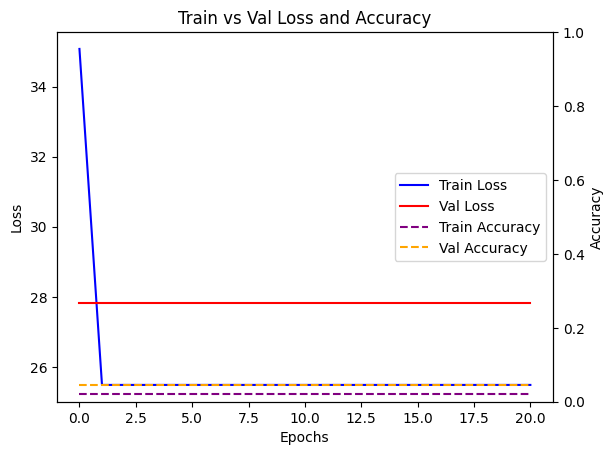

Training Defenders --------------------------------------------------
Epoch 0, Train Loss: 17.3042, Train Accuracy: 0.0323
Total time: 0.3298s, Val Loss: 18.2395, Val Accuracy: 0.0510
Epoch 10, Train Loss: 15.4133, Train Accuracy: 0.0323
Total time: 0.3461s, Val Loss: 18.2395, Val Accuracy: 0.0510
Going nowhere, epoch 20


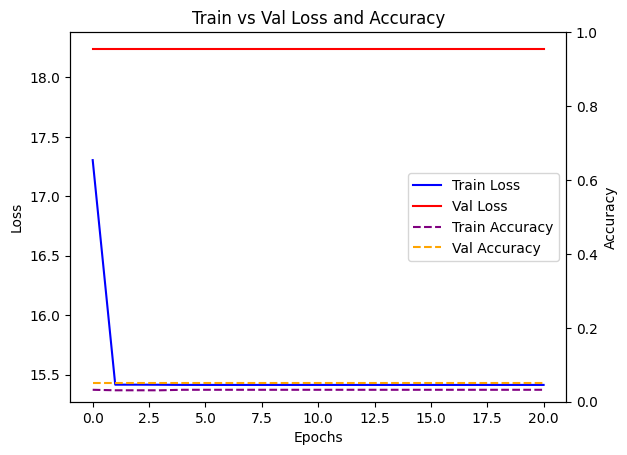

Training Midfielders --------------------------------------------------
Epoch 0, Train Loss: 19.9182, Train Accuracy: 0.0247
Total time: 0.2965s, Val Loss: 23.5607, Val Accuracy: 0.0075
Epoch 10, Train Loss: 19.9182, Train Accuracy: 0.0247
Total time: 0.3477s, Val Loss: 23.5607, Val Accuracy: 0.0075
Going nowhere, epoch 20


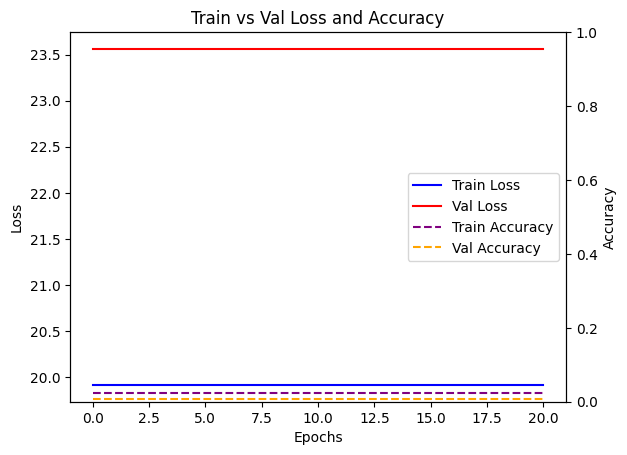

Training Goalkeepers --------------------------------------------------
Epoch 0, Train Loss: 11.9353, Train Accuracy: 0.1792
Total time: 0.0867s, Val Loss: 11.0017, Val Accuracy: 0.1379
Epoch 10, Train Loss: 11.9298, Train Accuracy: 0.1792
Total time: 0.0887s, Val Loss: 11.0017, Val Accuracy: 0.1379
Going nowhere, epoch 20


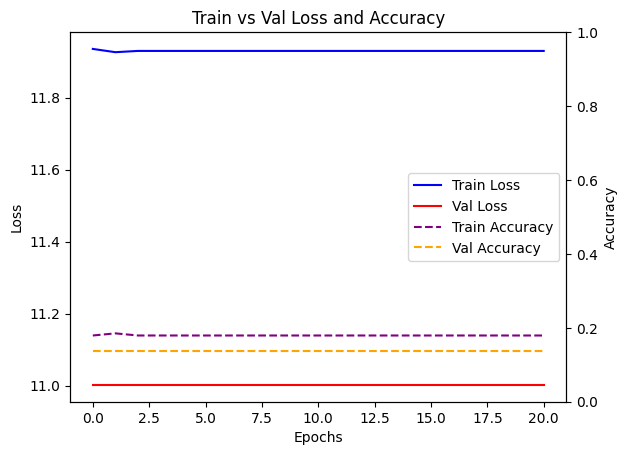

Training Full Dataset --------------------------------------------------
Epoch 0, Train Loss: 18.9399, Train Accuracy: 0.0395
Total time: 0.9845s, Val Loss: 21.8556, Val Accuracy: 0.0420
Epoch 10, Train Loss: 18.9399, Train Accuracy: 0.0395
Total time: 1.0363s, Val Loss: 21.8556, Val Accuracy: 0.0420
Going nowhere, epoch 20


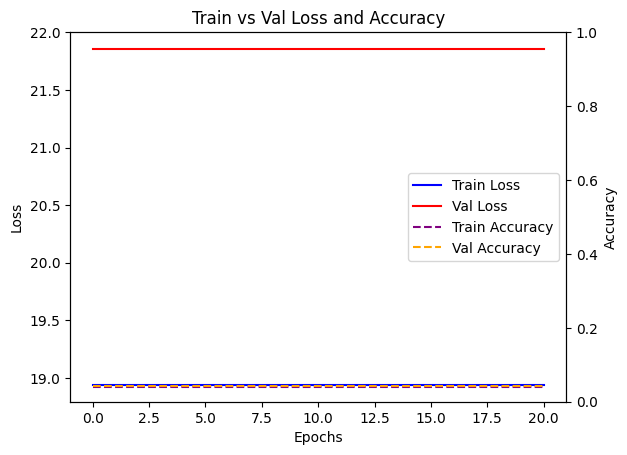

In [15]:
# paths to save to file
path_fw = 'models/fw/start_best.pt'
path_df = 'models/df/start_best.pt'
path_mf = 'models/mf/start_best.pt'
path_gk = 'models/gk/start_best.pt'
path_full = 'models/full/start_best.pt'


bestest = 10000
num_epochs = 200

# Create model
start_fw = Start()

# Check if there is an already trained set of weights and use that to start
if os.path.exists(path_fw):
    checkpoint = torch.load(path_fw, weights_only=True)
    bestest = checkpoint['loss']
    start_fw.load_state_dict(checkpoint['model_state_dict'])

#Create loss, optimization and run training
crit = nn.L1Loss()
opt = optim.Adam(start_fw.parameters())    
print('Training Forwards', "-"*50)
plotter(looper(start_fw, opt, crit, num_epochs, trainload_fw, valload_fw, bestest, path_fw))

# Same for Defenders
bestest = 10000
start_df = Start()

if os.path.exists(path_df):
    checkpoint = torch.load(path_df, weights_only=True)
    bestest = checkpoint['loss']
    start_df.load_state_dict(checkpoint['model_state_dict'])

crit = nn.L1Loss()
opt = optim.Adam(start_df.parameters())    
print('Training Defenders', "-"*50)    

plotter(looper(start_df, opt, crit, num_epochs, trainload_df, valload_df, bestest, path_df))

# Same for Midfielders
bestest = 10000
start_mf = Start()

if os.path.exists(path_mf):
    checkpoint = torch.load(path_mf, weights_only=True)
    bestest = checkpoint['loss']
    start_mf.load_state_dict(checkpoint['model_state_dict'])

crit = nn.L1Loss()
opt = optim.Adam(start_mf.parameters())    
print('Training Midfielders', "-"*50)    

plotter(looper(start_mf, opt, crit, num_epochs, trainload_mf, valload_mf, bestest, path_mf))

# Same for Goalkeepers
bestest = 10000
start_gk = Start(gk=True)

if os.path.exists(path_gk):
    checkpoint = torch.load(path_gk, weights_only=True)
    bestest = checkpoint['loss']
    start_gk.load_state_dict(checkpoint['model_state_dict'])

crit = nn.L1Loss()
opt = optim.Adam(start_gk.parameters())    
print('Training Goalkeepers', "-"*50)    

plotter(looper(start_gk, opt, crit, num_epochs, trainload_gk, valload_gk, bestest, path_gk))

# Same for Full dataset
bestest = 10000
start_full = Start(gk=True)

if os.path.exists(path_full):
    checkpoint = torch.load(path_full, weights_only=True)
    bestest = checkpoint['loss']
    start_full.load_state_dict(checkpoint['model_state_dict'])

crit = nn.L1Loss()
opt = optim.Adam(start_full.parameters())    
print('Training Full Dataset', "-"*50)    

plotter(looper(start_full, opt, crit, num_epochs, trainload_full, valload_full,bestest, path_full))




As one would expect with only having 141 trainable parameters, the models did not learn anything and guessed very poorly. The goalkeeper set was the best learned set, which makes sense because they have more data to learn from as well as less variation in their important features.

# Adding more layers

In [16]:
class Net1(nn.Module):
    def __init__(self, gk=False):
        super(Net1, self).__init__()
        self.relu = nn.ReLU()
        if gk:
            self.layer1 = nn.Linear(140,128)
            self.layer2 = nn.Linear(128,64)
            self.layer3 = nn.Linear(64,64)
            self.layer4 = nn.Linear(64,32)
            self.layer5 = nn.Linear(32,16)
            self.layer6 = nn.Linear(16,4)
            self.layer7 = nn.Linear(4,1)
        else:
            self.layer1 = nn.Linear(113, 128)
            self.layer2 = nn.Linear(128,64)
            self.layer3 = nn.Linear(64,64)
            self.layer4 = nn.Linear(64,32)
            self.layer5 = nn.Linear(32,16)
            self.layer6 = nn.Linear(16,4)
            self.layer7 = nn.Linear(4,1)
        
        
    def forward(self,x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.relu(self.layer4(x))
        x = self.relu(self.layer5(x))
        x = self.relu(self.layer6(x))
        return self.relu(self.layer7(x))

In [17]:
summary(Net1(), (1,113))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 1, 128]          14,592
              ReLU-2               [-1, 1, 128]               0
            Linear-3                [-1, 1, 64]           8,256
              ReLU-4                [-1, 1, 64]               0
            Linear-5                [-1, 1, 64]           4,160
              ReLU-6                [-1, 1, 64]               0
            Linear-7                [-1, 1, 32]           2,080
              ReLU-8                [-1, 1, 32]               0
            Linear-9                [-1, 1, 16]             528
             ReLU-10                [-1, 1, 16]               0
           Linear-11                 [-1, 1, 4]              68
             ReLU-12                 [-1, 1, 4]               0
           Linear-13                 [-1, 1, 1]               5
             ReLU-14                 [-

Training Forwards --------------------------------------------------
Epoch 0, Train Loss: 25.4838, Train Accuracy: 0.0204
Total time: 0.7641s, Val Loss: 27.8100, Val Accuracy: 0.0455
Epoch 10, Train Loss: 25.4838, Train Accuracy: 0.0204
Total time: 0.7750s, Val Loss: 27.8100, Val Accuracy: 0.0455
Going nowhere, epoch 20


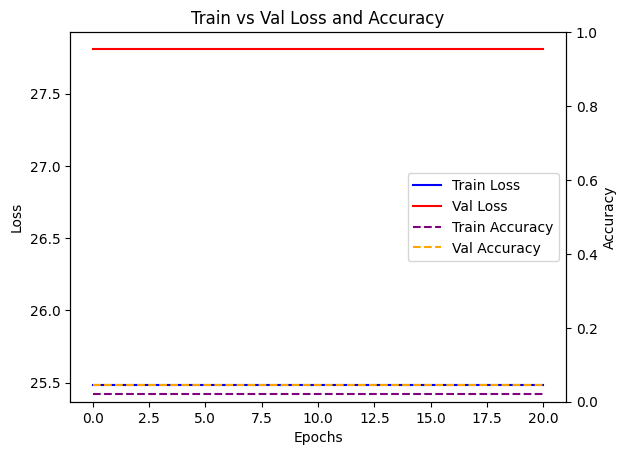

Training Defenders --------------------------------------------------
Epoch 0, Train Loss: 14.7887, Train Accuracy: 0.0592
Total time: 1.3840s, Val Loss: 17.1186, Val Accuracy: 0.0955
Epoch 10, Train Loss: 11.2211, Train Accuracy: 0.1063
Total time: 1.2643s, Val Loss: 13.9088, Val Accuracy: 0.0510
Epoch 20, Train Loss: 10.5988, Train Accuracy: 0.1104
Total time: 1.3308s, Val Loss: 12.9112, Val Accuracy: 0.0573
Epoch 30, Train Loss: 10.4846, Train Accuracy: 0.0834
Total time: 1.2468s, Val Loss: 12.5695, Val Accuracy: 0.0573
Epoch 40, Train Loss: 10.4300, Train Accuracy: 0.0740
Total time: 1.2317s, Val Loss: 12.3406, Val Accuracy: 0.0828
Epoch 50, Train Loss: 10.4081, Train Accuracy: 0.0767
Total time: 1.2387s, Val Loss: 12.2037, Val Accuracy: 0.0828
Epoch 60, Train Loss: 10.3953, Train Accuracy: 0.0740
Total time: 1.2874s, Val Loss: 12.0935, Val Accuracy: 0.0828
Epoch 70, Train Loss: 10.3949, Train Accuracy: 0.0633
Total time: 1.2171s, Val Loss: 12.0944, Val Accuracy: 0.0828
Epoch 80, T

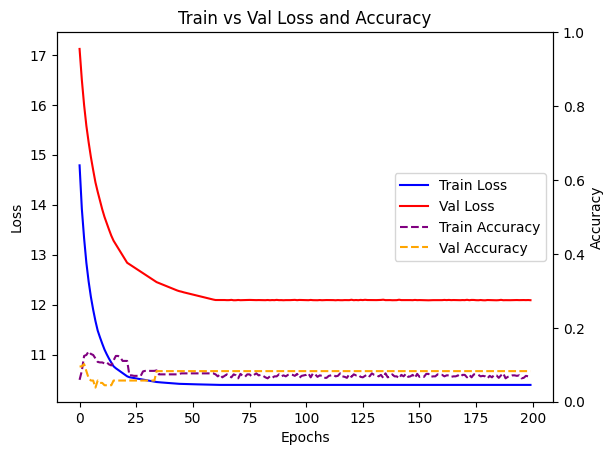

Training Midfielders --------------------------------------------------
Epoch 0, Train Loss: 19.9182, Train Accuracy: 0.0247
Total time: 1.0417s, Val Loss: 23.5662, Val Accuracy: 0.0075
Epoch 10, Train Loss: 19.9182, Train Accuracy: 0.0247
Total time: 1.0465s, Val Loss: 23.5662, Val Accuracy: 0.0075
Going nowhere, epoch 20


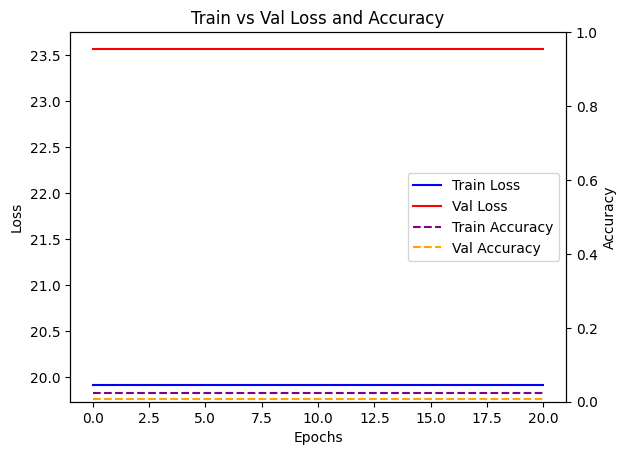

Training Goalkeepers --------------------------------------------------
Epoch 0, Train Loss: 11.9298, Train Accuracy: 0.1792
Total time: 0.2542s, Val Loss: 11.0017, Val Accuracy: 0.1379
Epoch 10, Train Loss: 11.9298, Train Accuracy: 0.1792
Total time: 0.2766s, Val Loss: 11.0017, Val Accuracy: 0.1379
Going nowhere, epoch 20


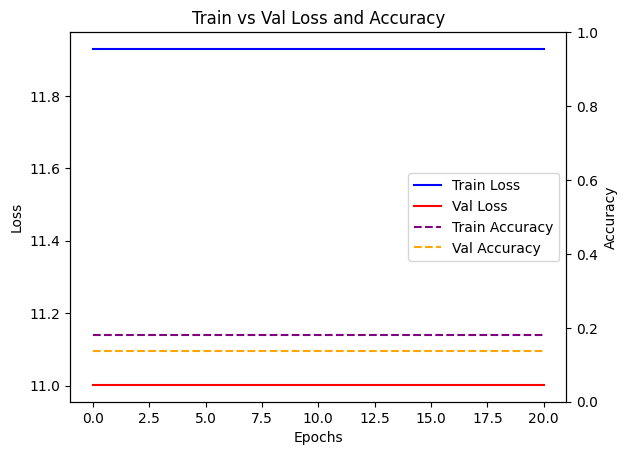

Training Full Dataset --------------------------------------------------
Epoch 0, Train Loss: 11.3700, Train Accuracy: 0.1189
Total time: 3.2109s, Val Loss: 13.4590, Val Accuracy: 0.0769
Epoch 10, Train Loss: 9.1457, Train Accuracy: 0.1379
Total time: 3.6121s, Val Loss: 10.4274, Val Accuracy: 0.0816
Epoch 20, Train Loss: 8.9236, Train Accuracy: 0.1058
Total time: 3.6708s, Val Loss: 12.0513, Val Accuracy: 0.0979
Epoch 30, Train Loss: 8.5737, Train Accuracy: 0.1267
Total time: 3.4948s, Val Loss: 10.5293, Val Accuracy: 0.0979
Epoch 40, Train Loss: 8.4610, Train Accuracy: 0.1316
Total time: 3.7679s, Val Loss: 9.8591, Val Accuracy: 0.0932
Epoch 50, Train Loss: 8.2488, Train Accuracy: 0.1213
Total time: 3.9433s, Val Loss: 10.4613, Val Accuracy: 0.0932
Epoch 60, Train Loss: 8.4051, Train Accuracy: 0.1184
Total time: 3.8824s, Val Loss: 9.7688, Val Accuracy: 0.0979
Epoch 70, Train Loss: 8.0450, Train Accuracy: 0.1267
Total time: 3.8119s, Val Loss: 10.6287, Val Accuracy: 0.0932
Epoch 80, Train L

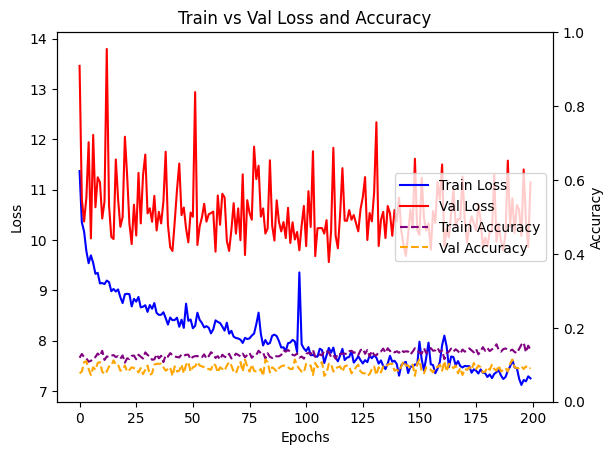

In [18]:
path_fw = 'models/fw/net1_best.pt'
path_df = 'models/df/net1_best.pt'
path_mf = 'models/mf/net1_best.pt'
path_gk = 'models/gk/net1_best.pt'
path_full = 'models/full/net1_best.pt'


bestest = 10000
num_epochs = 200
    
net1_fw = Net1()

if os.path.exists(path_fw):
    checkpoint = torch.load(path_fw, weights_only=True)
    bestest = checkpoint['loss']
    net1_fw.load_state_dict(checkpoint['model_state_dict'])

crit = nn.L1Loss()
opt = optim.Adam(net1_fw.parameters())    
print('Training Forwards', "-"*50)
plotter(looper(net1_fw, opt, crit, num_epochs, trainload_fw, valload_fw, bestest, path_fw))


bestest = 10000
net1_df = Net1()

if os.path.exists(path_df):
    checkpoint = torch.load(path_df, weights_only=True)
    bestest = checkpoint['loss']
    net1_df.load_state_dict(checkpoint['model_state_dict'])

crit = nn.L1Loss()
opt = optim.Adam(net1_df.parameters())    
print('Training Defenders', "-"*50)    

plotter(looper(net1_df, opt, crit, num_epochs, trainload_df, valload_df, bestest, path_df))

bestest = 10000
net1_mf = Net1()

if os.path.exists(path_mf):
    checkpoint = torch.load(path_mf, weights_only=True)
    bestest = checkpoint['loss']
    net1_mf.load_state_dict(checkpoint['model_state_dict'])

crit = nn.L1Loss()
opt = optim.Adam(net1_mf.parameters())    
print('Training Midfielders', "-"*50)    

plotter(looper(net1_mf, opt, crit, num_epochs, trainload_mf, valload_mf, bestest, path_mf))

bestest = 10000
net1_gk = Net1(gk=True)

if os.path.exists(path_gk):
    checkpoint = torch.load(path_gk, weights_only=True)
    bestest = checkpoint['loss']
    net1_gk.load_state_dict(checkpoint['model_state_dict'])

crit = nn.L1Loss()
opt = optim.Adam(net1_gk.parameters())    
print('Training Goalkeepers', "-"*50)    

plotter(looper(net1_gk, opt, crit, num_epochs, trainload_gk, valload_gk, bestest, path_gk))

bestest = 10000
net1_full = Net1(gk=True)

if os.path.exists(path_full):
    checkpoint = torch.load(path_full, weights_only=True)
    bestest = checkpoint['loss']
    net1_full.load_state_dict(checkpoint['model_state_dict'])

crit = nn.L1Loss()
opt = optim.Adam(net1_full.parameters())    
print('Training Full Dataset', "-"*50)    

plotter(looper(net1_full, opt, crit, num_epochs, trainload_full, valload_full,bestest, path_full))

Using a simple model that decreases by a power of two each layer seemed to do just as bad as the starting model I created and the weights learned essentially nothing. This time, only the full set was somewhat learned but still very poor at getting learning the training data even. 

## Modifying Parameters

For the first two experiments I used the Adam optimizer and L1loss, but L1loss is not penalizing enough when the model guesses very far away from the given market value. So I will be using MSELoss from now on to penalize the model more harshly. 

In [21]:
class Net2(nn.Module):
    def __init__(self, gk=False):
        super(Net2, self).__init__()
        self.relu = nn.ReLU()
        if gk:
            self.layer1 = nn.Linear(140,128)
            self.layer2 = nn.Linear(128,128)
            self.layer3 = nn.Linear(128,64)
            self.layer4 = nn.Linear(64,16)
            self.layer5 = nn.Linear(16,8)
            self.layer6 = nn.Linear(8,4)
            self.layer7 = nn.Linear(4,1)
        else:
            self.layer1 = nn.Linear(113, 128)
            self.layer2 = nn.Linear(128,128)
            self.layer3 = nn.Linear(128,64)
            self.layer4 = nn.Linear(64,16)
            self.layer5 = nn.Linear(16,8)
            self.layer6 = nn.Linear(8,4)
            self.layer7 = nn.Linear(4,1)
        
        
    def forward(self,x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.relu(self.layer4(x))
        x = self.relu(self.layer5(x))
        x = self.relu(self.layer6(x))
        return self.relu(self.layer7(x))

In [22]:
summary(Net2(), (1,113))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1               [-1, 1, 128]          14,592
              ReLU-2               [-1, 1, 128]               0
            Linear-3               [-1, 1, 128]          16,512
              ReLU-4               [-1, 1, 128]               0
            Linear-5                [-1, 1, 64]           8,256
              ReLU-6                [-1, 1, 64]               0
            Linear-7                [-1, 1, 16]           1,040
              ReLU-8                [-1, 1, 16]               0
            Linear-9                 [-1, 1, 8]             136
             ReLU-10                 [-1, 1, 8]               0
           Linear-11                 [-1, 1, 4]              36
             ReLU-12                 [-1, 1, 4]               0
           Linear-13                 [-1, 1, 1]               5
             ReLU-14                 [-

Training Forwards --------------------------------------------------
Epoch 0, Time: 0.79sec
Train Loss: 61.7649, Train Accuracy: 0.2188
Valid Loss: 223.5194, Valid Accuracy: 0.0636
Epoch 20, Time: 0.77sec
Train Loss: 51.7431, Train Accuracy: 0.2393
Valid Loss: 224.7076, Valid Accuracy: 0.0364
Epoch 40, Time: 0.78sec
Train Loss: 43.5956, Train Accuracy: 0.2352
Valid Loss: 199.0345, Valid Accuracy: 0.0545
Epoch 60, Time: 0.80sec
Train Loss: 38.1796, Train Accuracy: 0.2720
Valid Loss: 190.1553, Valid Accuracy: 0.0818
Epoch 80, Time: 0.84sec
Train Loss: 52.7920, Train Accuracy: 0.2352
Valid Loss: 224.6074, Valid Accuracy: 0.0545
Epoch 100, Time: 0.79sec
Train Loss: 55.9145, Train Accuracy: 0.2372
Valid Loss: 203.4786, Valid Accuracy: 0.0545
Epoch 120, Time: 0.86sec
Train Loss: 54.6620, Train Accuracy: 0.2372
Valid Loss: 271.9103, Valid Accuracy: 0.0727
Epoch 140, Time: 0.82sec
Train Loss: 53.1271, Train Accuracy: 0.2495
Valid Loss: 202.5848, Valid Accuracy: 0.1000
Epoch 160, Time: 0.91sec


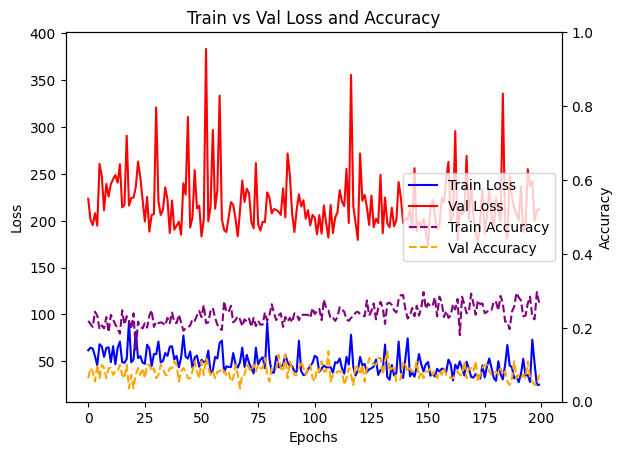

Training Defenders --------------------------------------------------
Epoch 0, Time: 1.12sec
Train Loss: 87.2791, Train Accuracy: 0.1279
Valid Loss: 206.3201, Valid Accuracy: 0.0764
Epoch 20, Time: 1.21sec
Train Loss: 252.6346, Train Accuracy: 0.0713
Valid Loss: 312.5614, Valid Accuracy: 0.0828
Epoch 40, Time: 1.38sec
Train Loss: 227.7670, Train Accuracy: 0.0162
Valid Loss: 270.3350, Valid Accuracy: 0.0446
Epoch 60, Time: 1.25sec
Train Loss: 224.0973, Train Accuracy: 0.0579
Valid Loss: 259.7294, Valid Accuracy: 0.0573
Epoch 80, Time: 1.22sec
Train Loss: 223.5841, Train Accuracy: 0.0633
Valid Loss: 256.6104, Valid Accuracy: 0.0701
Epoch 100, Time: 1.31sec
Train Loss: 223.5113, Train Accuracy: 0.0633
Valid Loss: 255.5565, Valid Accuracy: 0.0701
Epoch 120, Time: 1.41sec
Train Loss: 223.5002, Train Accuracy: 0.0633
Valid Loss: 255.1654, Valid Accuracy: 0.0701
Epoch 140, Time: 1.41sec
Train Loss: 223.5011, Train Accuracy: 0.0633
Valid Loss: 255.0522, Valid Accuracy: 0.0701
Epoch 160, Time: 

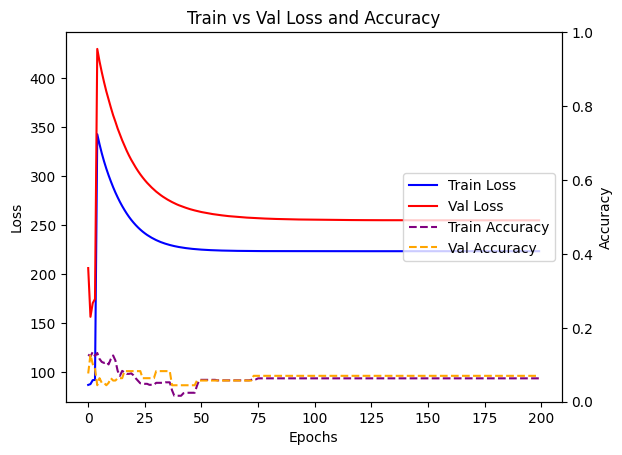

Training Midfielders --------------------------------------------------
Epoch 0, Time: 1.00sec
Train Loss: 795.0662, Train Accuracy: 0.0448
Valid Loss: 957.5609, Valid Accuracy: 0.0526
Epoch 20, Time: 1.19sec
Train Loss: 559.1001, Train Accuracy: 0.0726
Valid Loss: 671.7069, Valid Accuracy: 0.0677
Epoch 40, Time: 1.15sec
Train Loss: 465.3102, Train Accuracy: 0.0216
Valid Loss: 543.4741, Valid Accuracy: 0.0301
Epoch 60, Time: 1.18sec
Train Loss: 434.3776, Train Accuracy: 0.0325
Valid Loss: 491.6534, Valid Accuracy: 0.0376
Epoch 80, Time: 1.19sec
Train Loss: 425.1377, Train Accuracy: 0.0510
Valid Loss: 470.7116, Valid Accuracy: 0.0526
Epoch 100, Time: 1.17sec
Train Loss: 422.4666, Train Accuracy: 0.0433
Valid Loss: 461.6883, Valid Accuracy: 0.0526
Epoch 120, Time: 1.22sec
Train Loss: 421.7046, Train Accuracy: 0.0510
Valid Loss: 457.4890, Valid Accuracy: 0.0602
Epoch 140, Time: 1.20sec
Train Loss: 421.4837, Train Accuracy: 0.0510
Valid Loss: 455.4257, Valid Accuracy: 0.0602
Epoch 160, Tim

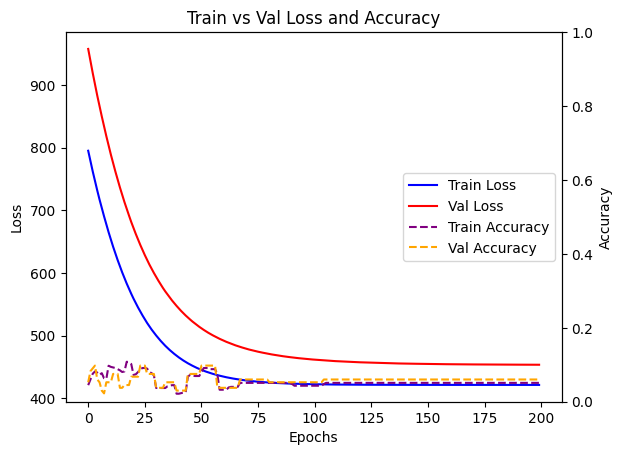

Training Goalkeepers --------------------------------------------------
Epoch 0, Time: 0.28sec
Train Loss: 107.0740, Train Accuracy: 0.2370
Valid Loss: 79.7958, Valid Accuracy: 0.2759
Epoch 20, Time: 0.29sec
Train Loss: 91.1090, Train Accuracy: 0.3121
Valid Loss: 95.6349, Valid Accuracy: 0.2069
Epoch 40, Time: 0.28sec
Train Loss: 93.3027, Train Accuracy: 0.3121
Valid Loss: 91.4927, Valid Accuracy: 0.2759
Epoch 60, Time: 0.26sec
Train Loss: 83.4008, Train Accuracy: 0.3584
Valid Loss: 246.5923, Valid Accuracy: 0.2069
Epoch 80, Time: 0.30sec
Train Loss: 100.7342, Train Accuracy: 0.2948
Valid Loss: 81.4092, Valid Accuracy: 0.2414
Epoch 100, Time: 0.31sec
Train Loss: 71.4269, Train Accuracy: 0.3006
Valid Loss: 83.0844, Valid Accuracy: 0.2069
Epoch 120, Time: 0.30sec
Train Loss: 79.4112, Train Accuracy: 0.2717
Valid Loss: 71.8522, Valid Accuracy: 0.2069
Epoch 140, Time: 0.28sec
Train Loss: 74.1284, Train Accuracy: 0.3179
Valid Loss: 61.2983, Valid Accuracy: 0.2069
Epoch 160, Time: 0.29sec
Tr

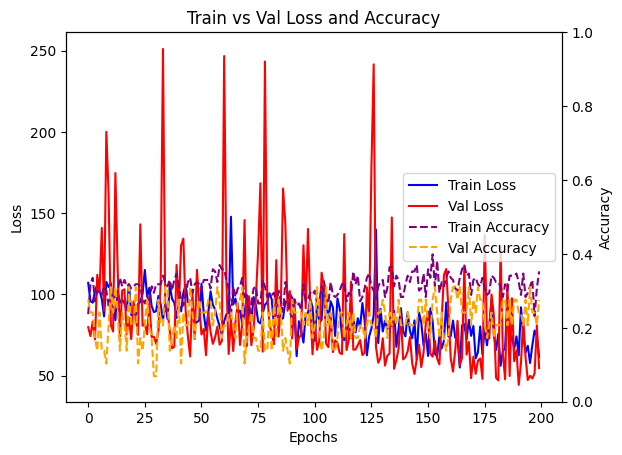

Training Full Dataset --------------------------------------------------
Epoch 0, Time: 3.50sec
Train Loss: 326.4822, Train Accuracy: 0.1053
Valid Loss: 375.7514, Valid Accuracy: 0.0862
Epoch 20, Time: 3.73sec
Train Loss: 194.8221, Train Accuracy: 0.0926
Valid Loss: 290.2535, Valid Accuracy: 0.0653
Epoch 40, Time: 3.93sec
Train Loss: 193.2163, Train Accuracy: 0.0975
Valid Loss: 220.5939, Valid Accuracy: 0.0839
Epoch 60, Time: 4.59sec
Train Loss: 185.0713, Train Accuracy: 0.0882
Valid Loss: 224.7928, Valid Accuracy: 0.0932
Epoch 80, Time: 4.36sec
Train Loss: 150.9042, Train Accuracy: 0.1028
Valid Loss: 207.8173, Valid Accuracy: 0.0839
Epoch 100, Time: 4.32sec
Train Loss: 147.1533, Train Accuracy: 0.1067
Valid Loss: 272.9580, Valid Accuracy: 0.0606
Epoch 120, Time: 4.45sec
Train Loss: 134.3952, Train Accuracy: 0.1087
Valid Loss: 209.3594, Valid Accuracy: 0.1119
Epoch 140, Time: 4.18sec
Train Loss: 126.9177, Train Accuracy: 0.1043
Valid Loss: 236.5556, Valid Accuracy: 0.0606
Epoch 160, Ti

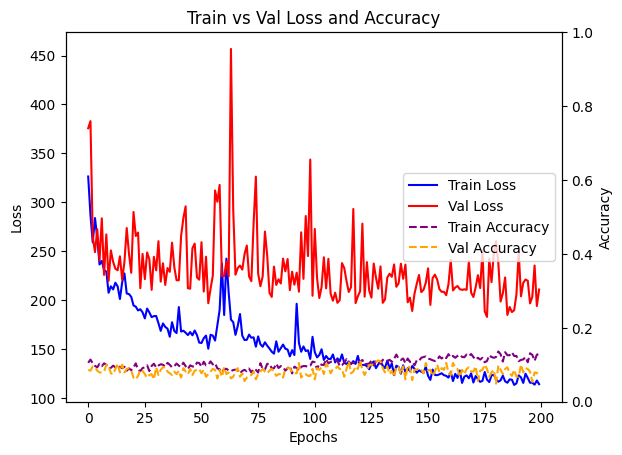

In [37]:
path_fw = 'models/fw/net2_best.pt'
path_df = 'models/df/net2_best.pt'
path_mf = 'models/mf/net2_best.pt'
path_gk = 'models/gk/net2_best.pt'
path_full = 'models/full/net2_best.pt'


bestest = 10000
num_epochs = 200
    
net2_fw = Net2()

if os.path.exists(path_fw):
    checkpoint = torch.load(path_fw, weights_only=True)
    bestest = checkpoint['loss']
    net2_fw.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
opt = optim.Adam(net2_fw.parameters())    
print('Training Forwards', "-"*50)
plotter(looper(net2_fw, opt, crit, num_epochs, trainload_fw, valload_fw, bestest, path_fw))


bestest = 10000
net2_df = Net2()

if os.path.exists(path_df):
    checkpoint = torch.load(path_df, weights_only=True)
    bestest = checkpoint['loss']
    net2_df.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
opt = optim.Adam(net2_df.parameters())    
print('Training Defenders', "-"*50)    

plotter(looper(net2_df, opt, crit, num_epochs, trainload_df, valload_df, bestest, path_df))

bestest = 10000
net2_mf = Net2()

if os.path.exists(path_mf):
    checkpoint = torch.load(path_mf, weights_only=True)
    bestest = checkpoint['loss']
    net2_mf.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
opt = optim.Adam(net2_mf.parameters())    
print('Training Midfielders', "-"*50)    

plotter(looper(net2_mf, opt, crit, num_epochs, trainload_mf, valload_mf, bestest, path_mf))

bestest = 10000
net2_gk = Net2(gk=True)

if os.path.exists(path_gk):
    checkpoint = torch.load(path_gk, weights_only=True)
    bestest = checkpoint['loss']
    net2_gk.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
opt = optim.Adam(net2_gk.parameters())    
print('Training Goalkeepers', "-"*50)    

plotter(looper(net2_gk, opt, crit, num_epochs, trainload_gk, valload_gk, bestest, path_gk))

bestest = 10000
net2_full = Net2(gk=True)

if os.path.exists(path_full):
    checkpoint = torch.load(path_full, weights_only=True)
    bestest = checkpoint['loss']
    net2_full.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
opt = optim.Adam(net2_full.parameters())    
print('Training Full Dataset', "-"*50)    

plotter(looper(net2_full, opt, crit, num_epochs, trainload_full, valload_full,bestest, path_full))

With the MSELoss, the model is starting to learn the training data a bit better, especially in the forward and goalkeeper datasets. The validation loss is not decreasing as much as the training loss, but again it is to be expected with the the nature of the outputs. 


## Training One Position at a time

Attempting to train all the positions at once on the same model, with independent weights is not going anywhere, and is a lot to keep track of at the same time. So going ahead I will start with finding a model that fits one training set well and attempt to apply it to the other sets. 

### Viewing outputs by layer

I came up with the idea to see the output of a certain layer from the model. To do this I had to modify my training loop and model so that they would comply with having multiple losses, optimizers, and weights.

Using the yield keyword, we can get the output of multiple layers and see the loss/accuracy from each layer to see how each layer performs.

In [ ]:
#Train
def layer_training(model, loader):
    model.train()
    # Initiate variables
    train_losses = []
    corrects = []
    correct = 0
    total = 0
    losses = []
    opts = []
    crits = []
    first = True
    for inputs, labels in loader:
        inputs = inputs.view(inputs.size(0), -1)
        
        # Since forward is technically a generator now, this works
        for j, out in enumerate(model(inputs)):
            # Only for first training data input
            if first:
                # Create optimizer for each output layer
                opt = optim.Adam(model.parameters())
                opt.zero_grad()
                loss = crit(out, labels)
                loss.backward(retain_graph=True)
                
                # Append loss and opt to list to access later
                losses.append(loss)
                opt.step()
                opts.append(opt)
                train_losses.append(losses[j].item())
                
                # Check how accurate
                if out[0] >= labels - 5 and out[0] <= labels + 5:
                    correct += 1  
                corrects.append(correct)
                correct = 0
                
            
            else:
                # For every time that wasn't the first:
                # do the same thing but access from list
                opts[j].zero_grad() 
                losses[j] = crit(out, labels)
                losses[j].backward(retain_graph=True)
                opts[j].step()
                train_losses[j] += losses[j].item()
                if out >= labels - 5 and out <= labels + 5:
                    corrects[j] += 1
                
        
        first = False    
        total += 1
    avg_losses =[]
    accs = []
    # Get losses and accuracies iteratively
    for k in range(len(train_losses)):
        avg_losses.append(train_losses[k] / len(loader))
        accs.append(corrects[k] / total)
    
    return avg_losses, accs



def layer_validate(model, loader):
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in loader:
            data = data.view(data.size(0), -1)
            layer_out = []
            # Same as normal validation but with the 
            # generator output for each layer
            for out in model(data):
                layer_out.append(out)
            print(layer_out)
            
            # Calculate loss
            loss = crit(outputs, target)
            val_loss += loss.item()
            if outputs >= target - 1 and outputs <= target + 1:
                correct += 1    
            total += 1
    
    avg_loss = val_loss / len(loader)
    accuracy = correct / total
    return avg_loss, accuracy

In [11]:
def layer_looper(model, crit, num_epochs, trainload, valload, bestest, path):

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []
    early = 0  
    pat = 21
    last = 0
    best = 0
    
    for epoch in range(num_epochs):
        s = time.perf_counter()
        tlosses, train_accuracies = layer_training(model, trainload)
        #vloss, val_accuracy = layer_validate(model, valload)
        print(f"Epoch {epoch}:")
        for i in range(len(tlosses)):
            print(f"Layer {i+1}:  Loss: {tlosses[i]:0.4f}  Accuracy: {train_accuracies[i]:0.4f}")
        

I created an *out* layer for each hidden layer so that I could see if there were earlier layers that could potentially have better losses. In the forward function, I have to create clones of the hidden layers so that the data of the actual layers would not be modified and cause errors in the backwards function.

In [77]:
class Net3(nn.Module):
    def __init__(self, gk=False):
        super(Net3, self).__init__()
        self.relu = nn.ReLU()
        if gk:
            self.layer1 = nn.Linear(140,128)
            self.layer2 = nn.Linear(128,128)
            self.layer3 = nn.Linear(128,64)
            self.layer4 = nn.Linear(64,16)
            self.layer5 = nn.Linear(16,8)
            self.layer6 = nn.Linear(8,4)
            self.layer7 = nn.Linear(4,1)
        else:
            self.layer1 = nn.Linear(113, 128)
            self.layer1_out = nn.Linear(128, 1)
            self.layer2 = nn.Linear(128,128)
            self.layer2_out = nn.Linear(128, 1)
            self.layer3 = nn.Linear(128,64)
            self.layer3_out = nn.Linear(64, 1)
            self.layer4 = nn.Linear(64,16)
            self.layer4_out = nn.Linear(16, 1)
            self.layer5 = nn.Linear(16,8)
            self.layer5_out = nn.Linear(8, 1)
            self.layer6 = nn.Linear(8,4)
            self.layer7 = nn.Linear(4,1)
        
        
    def forward(self,x):
        x = self.relu(nn.functional.linear(x, self.layer1.weight.clone(), self.layer1.bias))
        yield self.relu(self.layer1_out(x))
        x = self.relu(nn.functional.linear(x, self.layer2.weight.clone(), self.layer2.bias))
        yield self.relu(self.layer2_out(x))
        x = self.relu(nn.functional.linear(x, self.layer3.weight.clone(), self.layer3.bias))
        yield self.relu(self.layer3_out(x))
        x = self.relu(nn.functional.linear(x, self.layer4.weight.clone(), self.layer4.bias))
        yield self.relu(self.layer4_out(x))
        x = self.relu(nn.functional.linear(x, self.layer5.weight.clone(), self.layer5.bias))
        yield self.relu(self.layer5_out(x))
        x = self.relu(nn.functional.linear(x, self.layer6.weight.clone(), self.layer6.bias))
        yield self.relu(self.layer7(x))

In [76]:
path_mf = 'models/mf/net3_best.pt'

bestest = 10000
net3_mf = Net3()
num_epochs = 10

if os.path.exists(path_mf):
    checkpoint = torch.load(path_mf, weights_only=True)
    bestest = checkpoint['loss']
    net3_mf.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
#opt = optim.Adam(net3_mf.parameters())    
print('Training Midfielders', "-"*50)    

layer_looper(net3_mf, crit, num_epochs, trainload_mf, valload_mf, bestest, path_mf)


Training Midfielders --------------------------------------------------
Epoch 0:
Layer 1:  Loss: 832.5160  Accuracy: 0.0247
Layer 2:  Loss: 826.6818  Accuracy: 0.0247
Layer 3:  Loss: 817.6819  Accuracy: 0.0263
Layer 4:  Loss: 814.5339  Accuracy: 0.0247
Layer 5:  Loss: 798.4631  Accuracy: 0.0325
Layer 6:  Loss: 363.1596  Accuracy: 0.0974
Epoch 1:
Layer 1:  Loss: 903.0038  Accuracy: 0.0278
Layer 2:  Loss: 818.1046  Accuracy: 0.0247
Layer 3:  Loss: 824.9755  Accuracy: 0.0263
Layer 4:  Loss: 781.8716  Accuracy: 0.0247
Layer 5:  Loss: 534.1574  Accuracy: 0.0680
Layer 6:  Loss: 337.1247  Accuracy: 0.1036
Epoch 2:
Layer 1:  Loss: 818.0414  Accuracy: 0.0247
Layer 2:  Loss: 818.1046  Accuracy: 0.0247
Layer 3:  Loss: 818.1046  Accuracy: 0.0247
Layer 4:  Loss: 818.1046  Accuracy: 0.0247
Layer 5:  Loss: 319.7067  Accuracy: 0.1097
Layer 6:  Loss: 313.2578  Accuracy: 0.1144
Epoch 3:
Layer 1:  Loss: 862.3796  Accuracy: 0.0247
Layer 2:  Loss: 818.1046  Accuracy: 0.0247
Layer 3:  Loss: 818.1046  Accura

KeyboardInterrupt: 

Based on the accuracies from this test, we get relatively the same loss and accuracy when outputing from 8 neurons to 1 as when we output from 4 neurons to 1. The more generalization of data when the amount of neurons get smaller seems to not gain us any information so I probably should not be using a 4 neuron layer. (Looking back I forgot this almost immediately)

In [82]:
class Net4(nn.Module):
    def __init__(self, gk=False):
        super(Net4, self).__init__()
        self.relu = nn.ReLU()
        if gk:
            self.layer1 = nn.Linear(140,128)
            self.layer2 = nn.Linear(128,128)
            self.layer3 = nn.Linear(128,64)
            self.layer4 = nn.Linear(64,16)
            self.layer5 = nn.Linear(16,8)
            self.layer6 = nn.Linear(8,4)
            self.layer7 = nn.Linear(4,1)
        else:
            self.layer1 = nn.Linear(113, 128)
            self.layer2 = nn.Linear(128,128)
            self.layer3 = nn.Linear(128,128)
            self.layer4 = nn.Linear(128,128)
            self.layer4_out = nn.Linear(128, 1)
            self.layer5 = nn.Linear(128,64)
            self.layer5_out = nn.Linear(64, 1)
            self.layer6 = nn.Linear(64,16)
            self.layer6_out = nn.Linear(16, 1)
            self.layer7 = nn.Linear(16,8)
            self.layer8 = nn.Linear(8,1)
        
        
    def forward(self,x):
        x = self.relu(nn.functional.linear(x, self.layer1.weight.clone(), self.layer1.bias))
        x = self.relu(nn.functional.linear(x, self.layer2.weight.clone(), self.layer2.bias))
        x = self.relu(nn.functional.linear(x, self.layer3.weight.clone(), self.layer3.bias))
        x = self.relu(nn.functional.linear(x, self.layer4.weight.clone(), self.layer4.bias))
        yield self.relu(self.layer4_out(x))
        x = self.relu(nn.functional.linear(x, self.layer5.weight.clone(), self.layer5.bias))
        yield self.relu(self.layer5_out(x))
        x = self.relu(nn.functional.linear(x, self.layer6.weight.clone(), self.layer6.bias))
        yield self.relu(self.layer6_out(x))
        x = self.relu(self.layer7(x))
        yield self.relu(self.layer8(x))

In [84]:
path_mf = 'models/mf/net4_best.pt'

bestest = 10000
net4_mf = Net4()
num_epochs = 10

if os.path.exists(path_mf):
    checkpoint = torch.load(path_mf, weights_only=True)
    bestest = checkpoint['loss']
    net4_mf.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
#opt = optim.Adam(net3_mf.parameters())    
print('Training Midfielders', "-"*50)    

layer_looper(net4_mf, crit, num_epochs, trainload_mf, valload_mf, bestest, path_mf)


Training Midfielders --------------------------------------------------
Epoch 0:
Layer 1:  Loss: 818.8490  Accuracy: 0.0247
Layer 2:  Loss: 817.8303  Accuracy: 0.0247
Layer 3:  Loss: 532.3042  Accuracy: 0.0835
Layer 4:  Loss: 426.8839  Accuracy: 0.0866
Epoch 1:
Layer 1:  Loss: 818.1046  Accuracy: 0.0247
Layer 2:  Loss: 818.1046  Accuracy: 0.0247
Layer 3:  Loss: 443.9248  Accuracy: 0.1005
Layer 4:  Loss: 394.4134  Accuracy: 0.1036
Epoch 2:
Layer 1:  Loss: 818.1046  Accuracy: 0.0247
Layer 2:  Loss: 818.1046  Accuracy: 0.0247
Layer 3:  Loss: 382.1314  Accuracy: 0.0866
Layer 4:  Loss: 350.2040  Accuracy: 0.0866
Epoch 3:
Layer 1:  Loss: 410.3724  Accuracy: 0.0958
Layer 2:  Loss: 818.1046  Accuracy: 0.0247
Layer 3:  Loss: 368.2256  Accuracy: 0.1051
Layer 4:  Loss: 346.8409  Accuracy: 0.1051
Epoch 4:
Layer 1:  Loss: 435.7125  Accuracy: 0.1036
Layer 2:  Loss: 818.1046  Accuracy: 0.0247
Layer 3:  Loss: 409.5913  Accuracy: 0.1082
Layer 4:  Loss: 390.6278  Accuracy: 0.1036
Epoch 5:
Layer 1:  Loss

([],
 [],
 [0.10819165378670788,
  0.02472952086553323,
  0.10046367851622875,
  0.10046367851622875],
 [])

Based on the outputs of the model by layer, it looks like the model gets the same accuracies or better after **layer 1** (which is technically **layer 4** in the model) and then immediately drops accuracy when decreasing the amount of nodes in the model. The accuracy goes back up after, when decreasing the amount of nodes even more. But using this information, I want to attempt to just create layers that have the same dimension as the input and then immediately attempt to get a value, since it seems to be doing well in this test network.

So in the model below I created 7 layers which kept the dimension the same size, to really attempt to learn each datapoint.

In [87]:
class Net5(nn.Module):
    def __init__(self, gk=False):
        super(Net5, self).__init__()
        self.relu = nn.ReLU()
        if gk:
            self.layer1 = nn.Linear(140,128)
            self.layer2 = nn.Linear(128,128)
            self.layer3 = nn.Linear(128,64)
            self.layer4 = nn.Linear(64,16)
            self.layer5 = nn.Linear(16,8)
            self.layer6 = nn.Linear(8,4)
            self.layer7 = nn.Linear(4,1)
        else:
            self.l1 = nn.Linear(113, 113)
            self.l2 = nn.Linear(113, 113)
            self.l3 = nn.Linear(113, 113)
            self.l4 = nn.Linear(113, 113)
            self.l5 = nn.Linear(113, 113)
            self.l6 = nn.Linear(113, 113)
            self.l7 = nn.Linear(113, 113)
            self.l8 = nn.Linear(113, 1)
        
        
    def forward(self,x):
        x = self.relu(self.l1(x))
        x = self.relu(self.l2(x))
        x = self.relu(self.l3(x))
        x = self.relu(self.l4(x))
        x = self.relu(self.l5(x))
        x = self.relu(self.l6(x))
        x = self.relu(self.l7(x))
        return self.relu(self.l8(x)

Training Midfielders --------------------------------------------------
Epoch 0, Time: 12.35sec
Train Loss: 445.3943, Train Accuracy: 0.0974
Valid Loss: 275.1650, Valid Accuracy: 0.0752
Epoch 20, Time: 12.98sec
Train Loss: 259.2281, Train Accuracy: 0.1020
Valid Loss: 389.4666, Valid Accuracy: 0.0752
Epoch 40, Time: 12.86sec
Train Loss: 315.1909, Train Accuracy: 0.1082
Valid Loss: 649.5379, Valid Accuracy: 0.0602
Epoch 60, Time: 12.80sec
Train Loss: 242.2041, Train Accuracy: 0.0974
Valid Loss: 272.2338, Valid Accuracy: 0.0902
Epoch 80, Time: 12.69sec
Train Loss: 203.0489, Train Accuracy: 0.1066
Valid Loss: 201.3101, Valid Accuracy: 0.0977


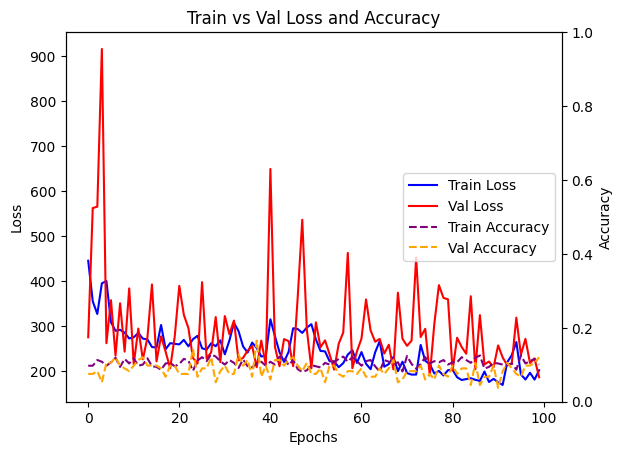

In [88]:
path_mf = 'models/mf/net5_best.pt'
bestest = 10000
net5_mf = Net5()
num_epochs = 101

if os.path.exists(path_mf):
    checkpoint = torch.load(path_mf, weights_only=True)
    bestest = checkpoint['loss']
    net5_mf.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
opt = optim.Adam(net5_mf.parameters())    
print('Training Midfielders', "-"*50)    

plotter(looper(net5_mf, opt, crit, num_epochs, trainload_mf, valload_mf, bestest, path_mf))


Training Midfielders --------------------------------------------------
Epoch 0, Time: 12.61sec
Train Loss: 213.6116, Train Accuracy: 0.1005
Valid Loss: 254.4234, Valid Accuracy: 0.0902
Epoch 20, Time: 12.52sec
Train Loss: 167.3165, Train Accuracy: 0.1221
Valid Loss: 257.8093, Valid Accuracy: 0.0526
Epoch 40, Time: 12.44sec
Train Loss: 228.0478, Train Accuracy: 0.0974
Valid Loss: 302.2000, Valid Accuracy: 0.0752
Epoch 60, Time: 13.10sec
Train Loss: 155.7047, Train Accuracy: 0.0943
Valid Loss: 218.9498, Valid Accuracy: 0.1053
Epoch 80, Time: 13.70sec
Train Loss: 137.6594, Train Accuracy: 0.1128
Valid Loss: 221.6708, Valid Accuracy: 0.0677
Epoch 100, Time: 13.22sec
Train Loss: 139.2670, Train Accuracy: 0.1175
Valid Loss: 184.8015, Valid Accuracy: 0.1053
Epoch 120, Time: 13.16sec
Train Loss: 123.3181, Train Accuracy: 0.1175
Valid Loss: 178.0066, Valid Accuracy: 0.0977
Epoch 140, Time: 13.29sec
Train Loss: 190.8535, Train Accuracy: 0.0788
Valid Loss: 323.4454, Valid Accuracy: 0.0977
Epoch 

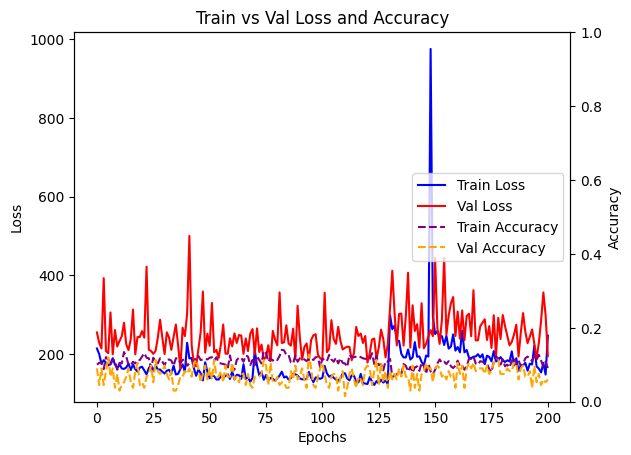

In [89]:
path_mf = 'models/mf/net5_best.pt'
bestest = 10000
net5_mf = Net5()
num_epochs = 201

if os.path.exists(path_mf):
    checkpoint = torch.load(path_mf, weights_only=True)
    bestest = checkpoint['loss']
    net5_mf.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
opt = optim.Adam(net5_mf.parameters())    
print('Training Midfielders', "-"*50)    

plotter(looper(net5_mf, opt, crit, num_epochs, trainload_mf, valload_mf, bestest, path_mf))


This novel idea I had, did not really have any big increases in accuracy, even after 300 training epochs, which is unfortunate because I thought the more neurons that each layer had, the model would learn the data better. 

Because I still believe this idea could work I decided to go through each layer and create a matching output layer to compare accuracies by layer.

In [14]:
class TestNet(nn.Module):
    def __init__(self, gk=False):
        super(TestNet, self).__init__()
        self.relu = nn.ReLU()
        if gk:
            self.layer1 = nn.Linear(140,128)
            self.layer2 = nn.Linear(128,128)
            self.layer3 = nn.Linear(128,64)
            self.layer4 = nn.Linear(64,16)
            self.layer5 = nn.Linear(16,8)
            self.layer6 = nn.Linear(8,4)
            self.layer7 = nn.Linear(4,1)
        else:
            self.layer1 = nn.Linear(113, 113)
            self.layer1_out = nn.Linear(113,1)
            self.layer2 = nn.Linear(113, 113)
            self.layer2_out = nn.Linear(113,1)
            self.layer3 = nn.Linear(113, 113)
            self.layer3_out = nn.Linear(113,1)
            self.layer4 = nn.Linear(113, 113)
            self.layer4_out = nn.Linear(113,1)
            self.layer5 = nn.Linear(113, 113)
            self.layer5_out = nn.Linear(113,1)
            self.layer6 = nn.Linear(113, 113)
            self.layer6_out = nn.Linear(113,1)
            self.layer7 = nn.Linear(113, 113)
            self.layer7_out = nn.Linear(113,1)
            self.layer8 = nn.Linear(113, 113)
            self.layer8_out = nn.Linear(113,1)
            self.layer9 = nn.Linear(113, 113)
            self.layer9_out = nn.Linear(113,1)
            self.layer10 = nn.Linear(113, 113)
            self.layer10_out = nn.Linear(113,1)
            self.layer11 = nn.Linear(113, 113)
            self.layer12 = nn.Linear(113, 1)
        
        
    def forward(self,x):
        x = self.relu(nn.functional.linear(x, self.layer1.weight.clone(), self.layer1.bias))
        yield self.layer1_out(x)
        x = self.relu(nn.functional.linear(x, self.layer2.weight.clone(), self.layer2.bias))
        yield self.layer2_out(x)
        x = self.relu(nn.functional.linear(x, self.layer3.weight.clone(), self.layer3.bias))
        yield self.layer3_out(x)
        x = self.relu(nn.functional.linear(x, self.layer4.weight.clone(), self.layer4.bias))
        yield self.layer4_out(x)
        x = self.relu(nn.functional.linear(x, self.layer5.weight.clone(), self.layer5.bias))
        yield self.layer5_out(x)
        x = self.relu(nn.functional.linear(x, self.layer6.weight.clone(), self.layer6.bias))
        yield self.layer6_out(x)
        x = self.relu(nn.functional.linear(x, self.layer7.weight.clone(), self.layer7.bias))
        yield self.layer7_out(x)
        x = self.relu(nn.functional.linear(x, self.layer8.weight.clone(), self.layer8.bias))
        yield self.layer8_out(x)
        x = self.relu(nn.functional.linear(x, self.layer9.weight.clone(), self.layer9.bias))
        yield self.layer9_out(x)
        x = self.relu(nn.functional.linear(x, self.layer10.weight.clone(), self.layer10.bias))
        yield self.layer10_out(x)
        x = self.relu(self.layer11(x))
        yield self.layer12(x)

In [15]:
path_mf = 'models/mf/test1_best.pt'

bestest = 10000
test1_mf = TestNet()
num_epochs = 10

if os.path.exists(path_mf):
    checkpoint = torch.load(path_mf, weights_only=True)
    bestest = checkpoint['loss']
    test1_mf.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
#opt = optim.Adam(net3_mf.parameters())    
print('Training Midfielders', "-"*50)    

layer_looper(test1_mf, crit, num_epochs, trainload_mf, valload_mf, bestest, path_mf)


Training Midfielders --------------------------------------------------
Epoch 0:
Layer 1:  Loss: 6903.5438  Accuracy: 0.0278
Layer 2:  Loss: 1427.1780  Accuracy: 0.0526
Layer 3:  Loss: 723.9572  Accuracy: 0.0711
Layer 4:  Loss: 787.0758  Accuracy: 0.0680
Layer 5:  Loss: 847.8722  Accuracy: 0.0587
Layer 6:  Loss: 852.6866  Accuracy: 0.0464
Layer 7:  Loss: 721.7001  Accuracy: 0.0587
Layer 8:  Loss: 769.0189  Accuracy: 0.0510
Layer 9:  Loss: 797.9398  Accuracy: 0.0556
Layer 10:  Loss: 800.3330  Accuracy: 0.0603
Layer 11:  Loss: 775.5808  Accuracy: 0.0603
Epoch 1:
Layer 1:  Loss: 557.8174  Accuracy: 0.0742
Layer 2:  Loss: 594.7279  Accuracy: 0.0958
Layer 3:  Loss: 504.5978  Accuracy: 0.0912
Layer 4:  Loss: 575.7344  Accuracy: 0.0850
Layer 5:  Loss: 529.2041  Accuracy: 0.0958
Layer 6:  Loss: 535.3360  Accuracy: 0.0742
Layer 7:  Loss: 511.5066  Accuracy: 0.0927
Layer 8:  Loss: 549.7558  Accuracy: 0.1020
Layer 9:  Loss: 570.0683  Accuracy: 0.0711
Layer 10:  Loss: 548.2161  Accuracy: 0.0943
La

Looking at the accuracies by layer, they actually get worse as each layer is added. The best output layer on average is layer 3, and the losses increase each layer after that. Using this information I know that only having three hidden layers will give us the best accuracy, so I can use that as a base for the future models I will create.

And the first model I will create is again a model where each layer, after the first three will decrease the amount of neurons by a factor of 2. 

In [21]:
class Test2Net(nn.Module):
    def __init__(self, gk=False):
        super(Test2Net, self).__init__()
        self.relu = nn.ReLU()
        if gk:
            self.layer1 = nn.Linear(140,128)
            self.layer2 = nn.Linear(128,128)
            self.layer3 = nn.Linear(128,64)
            self.layer4 = nn.Linear(64,16)
            self.layer5 = nn.Linear(16,8)
            self.layer6 = nn.Linear(8,4)
            self.layer7 = nn.Linear(4,1)
        else:
            self.layer1 = nn.Linear(113, 113)
            self.layer2 = nn.Linear(113, 113)
            self.layer3 = nn.Linear(113, 113)
            self.layer3_out = nn.Linear(113,1)
            self.layer4 = nn.Linear(113, 64)
            self.layer4_out = nn.Linear(64,1)
            self.layer5 = nn.Linear(64, 64)
            self.layer5_out = nn.Linear(64,1)
            self.layer6 = nn.Linear(64, 32)
            self.layer6_out = nn.Linear(32,1)
            self.layer7 = nn.Linear(32, 16)
            self.layer7_out = nn.Linear(16,1)
            self.layer8 = nn.Linear(16, 8)
            self.layer8_out = nn.Linear(8,1)
            self.layer9 = nn.Linear(8, 4)
            #self.layer9_out = nn.Linear(4,1)
            self.layer10 = nn.Linear(4, 1)
            #self.layer10_out = nn.Linear(113,1)
            #self.layer11 = nn.Linear(113, 113)
            #self.layer12 = nn.Linear(113, 1)
        
        
    def forward(self,x):
        x = self.relu(nn.functional.linear(x, self.layer1.weight.clone(), self.layer1.bias))
        x = self.relu(nn.functional.linear(x, self.layer2.weight.clone(), self.layer2.bias))
        x = self.relu(nn.functional.linear(x, self.layer3.weight.clone(), self.layer3.bias))
        yield self.layer3_out(x)
        x = self.relu(nn.functional.linear(x, self.layer4.weight.clone(), self.layer4.bias))
        yield self.layer4_out(x)
        x = self.relu(nn.functional.linear(x, self.layer5.weight.clone(), self.layer5.bias))
        yield self.layer5_out(x)
        x = self.relu(nn.functional.linear(x, self.layer6.weight.clone(), self.layer6.bias))
        yield self.layer6_out(x)
        x = self.relu(nn.functional.linear(x, self.layer7.weight.clone(), self.layer7.bias))
        yield self.layer7_out(x)
        x = self.relu(nn.functional.linear(x, self.layer8.weight.clone(), self.layer8.bias))
        yield self.layer8_out(x)
        x = self.relu(nn.functional.linear(x, self.layer9.weight.clone(), self.layer9.bias))
        #yield self.layer9_out(x)
        #x = self.relu(nn.functional.linear(x, self.layer10.weight.clone(), self.layer10.bias))
        yield self.layer10(x)
        #x = self.relu(self.layer11(x))
        #yield self.layer12(x)

In [24]:
path_mf = 'models/mf/test2_best.pt'

bestest = 10000
test2_mf = Test2Net()
num_epochs = 10

if os.path.exists(path_mf):
    checkpoint = torch.load(path_mf, weights_only=True)
    bestest = checkpoint['loss']
    test2_mf.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
#opt = optim.Adam(net3_mf.parameters())    
print('Training Midfielders', "-"*50)    

layer_looper(test2_mf, crit, num_epochs, trainload_mf, valload_mf, bestest, path_mf)


Training Midfielders --------------------------------------------------


C:\Users\Alex Merino\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\nn\modules\loss.py:538: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0:
Layer 1:  Loss: 1953.0349  Accuracy: 0.0974
Layer 2:  Loss: 1532.0837  Accuracy: 0.0773
Layer 3:  Loss: 1148.8966  Accuracy: 0.1159
Layer 4:  Loss: 776.1601  Accuracy: 0.1236
Layer 5:  Loss: 648.6908  Accuracy: 0.1066
Layer 6:  Loss: 608.8595  Accuracy: 0.1128
Layer 7:  Loss: 608.2187  Accuracy: 0.1097
Epoch 1:
Layer 1:  Loss: 465.4799  Accuracy: 0.1298
Layer 2:  Loss: 530.1359  Accuracy: 0.0958
Layer 3:  Loss: 548.0721  Accuracy: 0.1298
Layer 4:  Loss: 516.2005  Accuracy: 0.1283
Layer 5:  Loss: 446.6941  Accuracy: 0.1437
Layer 6:  Loss: 451.9987  Accuracy: 0.1499
Layer 7:  Loss: 440.8742  Accuracy: 0.1499
Epoch 2:
Layer 1:  Loss: 410.1052  Accuracy: 0.1499
Layer 2:  Loss: 392.4590  Accuracy: 0.1252
Layer 3:  Loss: 471.0767  Accuracy: 0.1453
Layer 4:  Loss: 464.4195  Accuracy: 0.1360
Layer 5:  Loss: 400.5885  Accuracy: 0.1221
Layer 6:  Loss: 402.9970  Accuracy: 0.1267
Layer 7:  Loss: 393.3182  Accuracy: 0.1221
Epoch 3:
Layer 1:  Loss: 361.8762  Accuracy: 0.1159
Layer 2:  Loss:

Looking at the accuracies throughout each layer, they are all the highest accuracies I have seen so far for this dataset. This is also through only 10 epochs, so given more time, the model should do much better. 

I then recreated the model as a normal model with only one output, to correctly train and evaluate the accuracy of the model.

In [9]:
class Net6(nn.Module):
    def __init__(self):
        super(Net6, self).__init__()
        self.relu = nn.ReLU()
        self.layer1 = nn.Linear(113, 113)
        self.layer2 = nn.Linear(113, 113)
        self.layer3 = nn.Linear(113, 113)
        self.layer4 = nn.Linear(113, 64)
        self.layer5 = nn.Linear(64, 64)
        self.layer6 = nn.Linear(64, 32)
        self.layer7 = nn.Linear(32, 16)
        self.layer8 = nn.Linear(16, 8)
        self.layer9 = nn.Linear(8, 4)
        self.layer10 = nn.Linear(4, 1)
    
        
    def forward(self,x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.relu(self.layer4(x))
        x = self.relu(self.layer5(x))
        x = self.relu(self.layer6(x))
        x = self.relu(self.layer7(x))
        x = self.relu(self.layer8(x))
        x = self.relu(self.layer9(x))
        return self.layer10(x)

Training Midfielders --------------------------------------------------
Epoch 0, Time: 2.38sec
Train Loss: 465.2249, Train Accuracy: 0.1360
Valid Loss: 672.1316, Valid Accuracy: 0.0752
Epoch 20, Time: 2.55sec
Train Loss: 341.7316, Train Accuracy: 0.1453
Valid Loss: 526.1440, Valid Accuracy: 0.0602
Epoch 40, Time: 2.54sec
Train Loss: 328.5592, Train Accuracy: 0.1051
Valid Loss: 457.2491, Valid Accuracy: 0.0827
Epoch 60, Time: 2.58sec
Train Loss: 295.3172, Train Accuracy: 0.1159
Valid Loss: 424.7101, Valid Accuracy: 0.0677
Epoch 80, Time: 2.83sec
Train Loss: 283.9363, Train Accuracy: 0.1051
Valid Loss: 397.2763, Valid Accuracy: 0.0752
Epoch 100, Time: 2.61sec
Train Loss: 266.8661, Train Accuracy: 0.1159
Valid Loss: 362.2650, Valid Accuracy: 0.0677
Epoch 120, Time: 2.78sec
Train Loss: 262.6221, Train Accuracy: 0.0927
Valid Loss: 344.5745, Valid Accuracy: 0.0526
Epoch 140, Time: 2.88sec
Train Loss: 231.9506, Train Accuracy: 0.0943
Valid Loss: 318.4799, Valid Accuracy: 0.0827
Epoch 160, Tim

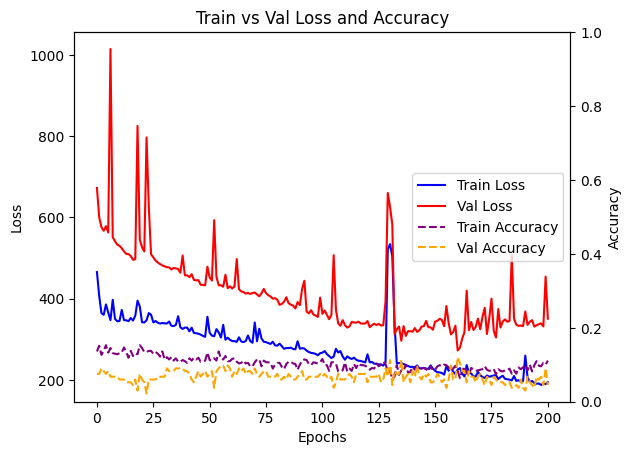

In [36]:
path_mf = 'models/mf/net6_best.pt'
bestest = 10000
net6_mf = Net6()
num_epochs = 201

if os.path.exists(path_mf):
    checkpoint = torch.load(path_mf, weights_only=True)
    bestest = checkpoint['loss']
    net6_mf.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
opt = optim.Adam(net6_mf.parameters())    
print('Training Midfielders', "-"*50)    

plotter(looper(net6_mf, opt, crit, num_epochs, trainload_mf, valload_mf, bestest, path_mf))


Training Midfielders --------------------------------------------------
Epoch 0, Time: 1.43sec
Train Loss: 43.9013, Train Accuracy within 1: 0.2226, Train Accuracy within 5: 0.7063
Valid Loss: 294.1401, Valid Accuracy within 1: 0.0902, Valid Accuracy within 5: 0.4361
Epoch 20, Time: 1.54sec
Train Loss: 74.5293, Train Accuracy within 1: 0.2257, Train Accuracy within 5: 0.6940
Valid Loss: 251.1036, Valid Accuracy within 1: 0.1203, Valid Accuracy within 5: 0.4060
Epoch 40, Time: 1.53sec
Train Loss: 38.1220, Train Accuracy within 1: 0.2226, Train Accuracy within 5: 0.7357
Valid Loss: 266.3636, Valid Accuracy within 1: 0.0677, Valid Accuracy within 5: 0.4060
Epoch 60, Time: 1.52sec
Train Loss: 97.0214, Train Accuracy within 1: 0.1762, Train Accuracy within 5: 0.5889
Valid Loss: 275.1877, Valid Accuracy within 1: 0.1128, Valid Accuracy within 5: 0.4436
Epoch 80, Time: 1.53sec
Train Loss: 84.8544, Train Accuracy within 1: 0.2056, Train Accuracy within 5: 0.6507
Valid Loss: 261.0221, Valid Acc

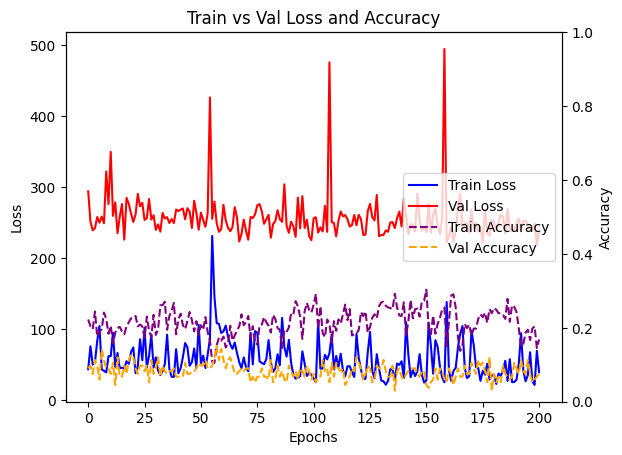

In [46]:
path_mf = 'models/mf/net6_best.pt'
bestest = 10000
net6_mf = Net6()
num_epochs = 201

if os.path.exists(path_mf):
    checkpoint = torch.load(path_mf, weights_only=True)
    bestest = checkpoint['loss']
    net6_mf.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
opt = optim.Adam(net6_mf.parameters())    
print('Training Midfielders', "-"*50)    

plotter(looper_train(net6_mf, opt, crit, num_epochs, trainload_mf, valload_mf, bestest, path_mf))


Here is where I realized that my loss has decreased over 10-fold than the first epoch, but the training and validation accuracy has barely increased. For the model to correctly predict the output, it has to be within 1 (million euros) of the actual value, which is 1/180 (+/- 0.55%) of the range of the total dataset. So as a secondary accuracy, I added an if statement to the training and testing functions to see the accuracy of the model within 5 (million euros) or +/- 2.77% of the range of the output values. 

In doing so, we can see that in some epochs the model is predicting 3/4ths of the training set within 5, which is very good, meaning that the model has essentially learned the training data very well, however the validation accuracy is still around 40% which is, again to be expected with the nature of the values we are trying to predict. 

Training Midfielders --------------------------------------------------
Epoch 0, Time: 1.48sec
Train Loss: 36.2185, Train Accuracy within 1: 0.2334, Train Accuracy within 5: 0.7666
Valid Loss: 244.6740, Valid Accuracy within 1: 0.0301, Valid Accuracy within 5: 0.3383
Epoch 20, Time: 1.54sec
Train Loss: 96.3074, Train Accuracy within 1: 0.1731, Train Accuracy within 5: 0.6260
Valid Loss: 247.0896, Valid Accuracy within 1: 0.0677, Valid Accuracy within 5: 0.3609
Epoch 40, Time: 1.56sec
Train Loss: 37.0291, Train Accuracy within 1: 0.2349, Train Accuracy within 5: 0.7743
Valid Loss: 247.6310, Valid Accuracy within 1: 0.0602, Valid Accuracy within 5: 0.4135
Epoch 60, Time: 1.54sec
Train Loss: 89.8044, Train Accuracy within 1: 0.1700, Train Accuracy within 5: 0.6615
Valid Loss: 221.5670, Valid Accuracy within 1: 0.0902, Valid Accuracy within 5: 0.3910
Epoch 80, Time: 1.48sec
Train Loss: 19.1524, Train Accuracy within 1: 0.3153, Train Accuracy within 5: 0.8284
Valid Loss: 264.8007, Valid Acc

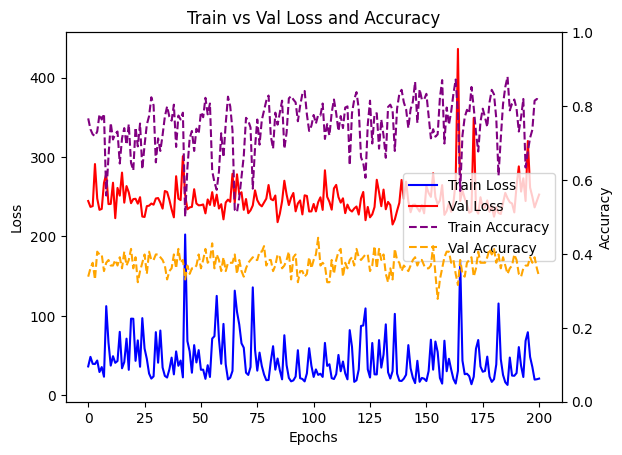

In [51]:
path_mf = 'models/mf/net6_best.pt'
bestest = 10000
net6_val_mf = Net6()
num_epochs = 201

if os.path.exists(path_mf):
    checkpoint = torch.load(path_mf, weights_only=True)
    #bestest = checkpoint['loss']
    net6_val_mf.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
opt = optim.Adam(net6_val_mf.parameters())    
print('Training Midfielders', "-"*50)    

plotter(looper_val(net6_val_mf, opt, crit, num_epochs, trainload_mf, valload_mf, bestest, 'models/mf/net6_val_best.pt'))


### Training Forwards

Training Forwards --------------------------------------------------
Epoch 0, Time: 2.30sec
Train Loss: 61.8863, Train Accuracy within 1: 0.1125, Train Accuracy within 5: 0.5317
Valid Loss: 325.8181, Valid Accuracy within 1: 0.0545, Valid Accuracy within 5: 0.3182
Epoch 20, Time: 1.94sec
Train Loss: 90.2518, Train Accuracy within 1: 0.0961, Train Accuracy within 5: 0.4601
Valid Loss: 276.1851, Valid Accuracy within 1: 0.0909, Valid Accuracy within 5: 0.3818
Epoch 40, Time: 2.02sec
Train Loss: 92.8103, Train Accuracy within 1: 0.1043, Train Accuracy within 5: 0.5010
Valid Loss: 304.4699, Valid Accuracy within 1: 0.0636, Valid Accuracy within 5: 0.3545
Epoch 60, Time: 2.07sec
Train Loss: 61.0172, Train Accuracy within 1: 0.1022, Train Accuracy within 5: 0.5603
Valid Loss: 255.5365, Valid Accuracy within 1: 0.0727, Valid Accuracy within 5: 0.3909
Epoch 80, Time: 1.95sec
Train Loss: 104.6810, Train Accuracy within 1: 0.1145, Train Accuracy within 5: 0.4519
Valid Loss: 299.1821, Valid Accur

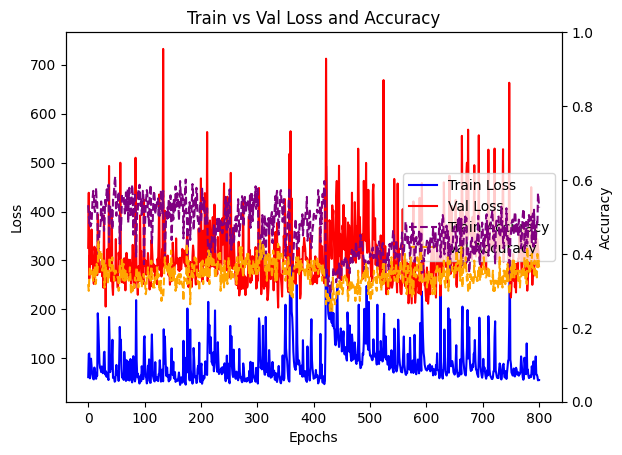

In [10]:
path_fw = 'models/fw/net6_best.pt'
path_val_fw = 'models/fw/net6_val_best.pt'
tbestest = 10000
vbestest = 10000
net6_fw = Net6()
num_epochs = 801

if os.path.exists(path_fw):
    checkpoint = torch.load(path_fw, weights_only=True)
    tbestest = checkpoint['loss']
    net6_fw.load_state_dict(checkpoint['model_state_dict'])
 
    
crit = nn.MSELoss()
opt = optim.Adam(net6_fw.parameters())    
print('Training Forwards', "-"*50)    

plotter(looper(net6_fw, opt, crit, num_epochs, trainload_fw, valload_fw, tbestest, vbestest, path_fw, path_val_fw))


### Training Full Dataset

Training Full Dataset --------------------------------------------------
Epoch 0, Time: 9.28sec
Train Loss: 406.4621, Train Accuracy within 1: 0.1559, Train Accuracy within 5: 0.5629
Valid Loss: 668.0139, Valid Accuracy within 1: 0.0699, Valid Accuracy within 5: 0.2564
Epoch 20, Time: 10.04sec
Train Loss: 453.7768, Train Accuracy within 1: 0.0526, Train Accuracy within 5: 0.2003
Valid Loss: 506.2327, Valid Accuracy within 1: 0.0559, Valid Accuracy within 5: 0.2821
Going nowhere, epoch 28


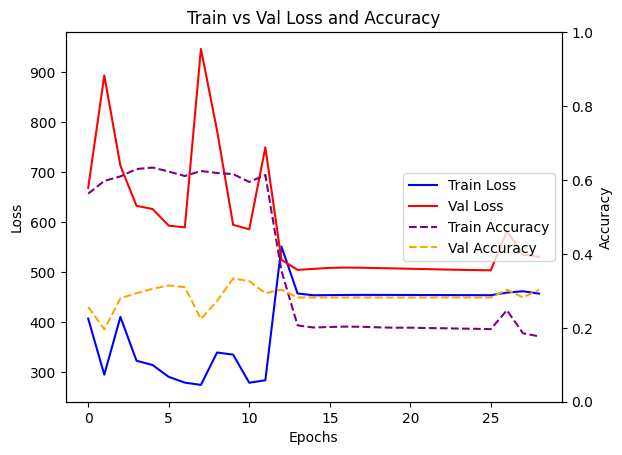

In [22]:
path_full = 'models/full/net6_best.pt'
path_val_full = 'models/full/net6_val_best.pt'
tbestest = 10000
vbestest = 10000
net6_full = Net6(True)
num_epochs = 801

if os.path.exists(path_full):
    checkpoint = torch.load(path_full, weights_only=True)
    tbestest = checkpoint['loss']
    net6_full.load_state_dict(checkpoint['model_state_dict'])
 
    
crit = nn.MSELoss()
opt = optim.Adam(net6_full.parameters())    
print('Training Full Dataset', "-"*50)    

plotter(looper(net6_full, opt, crit, num_epochs, trainload_full, valload_full, tbestest, vbestest, path_full, path_val_full))


### Training goalkeepers

Training Defenders --------------------------------------------------
Epoch 0, Time: 0.74sec
Train Loss: 11139691490.9104, Train Accuracy within 1: 0.0289, Train Accuracy within 5: 0.4393
Valid Loss: 258.9328, Valid Accuracy within 1: 0.0345, Valid Accuracy within 5: 0.4828
Epoch 20, Time: 0.81sec
Train Loss: 419.4245, Train Accuracy within 1: 0.0520, Train Accuracy within 5: 0.4335
Valid Loss: 252.8046, Valid Accuracy within 1: 0.0690, Valid Accuracy within 5: 0.4828
Epoch 40, Time: 0.82sec
Train Loss: 385.7033, Train Accuracy within 1: 0.2601, Train Accuracy within 5: 0.5318
Valid Loss: 220.4919, Valid Accuracy within 1: 0.3103, Valid Accuracy within 5: 0.5172
Epoch 60, Time: 0.80sec
Train Loss: 295.5082, Train Accuracy within 1: 0.0636, Train Accuracy within 5: 0.4740
Valid Loss: 139.7313, Valid Accuracy within 1: 0.0345, Valid Accuracy within 5: 0.3448
Epoch 80, Time: 0.82sec
Train Loss: 266.5404, Train Accuracy within 1: 0.0347, Train Accuracy within 5: 0.2197
Valid Loss: 121.3006

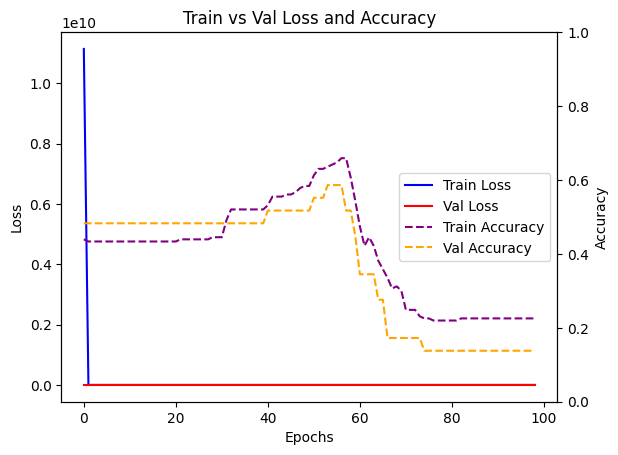

In [18]:
path_gk = 'models/gk/net6_best.pt'
path_val_gk = 'models/gk/net6_val_best.pt'
tbestest = 10000
vbestest = 10000
net6_gk = Net6(True)
num_epochs = 801

if os.path.exists(path_gk):
    checkpoint = torch.load(path_gk, weights_only=True)
    tbestest = checkpoint['loss']
    net6_gk.load_state_dict(checkpoint['model_state_dict'])
 
    
crit = nn.MSELoss()
opt = optim.Adam(net6_gk.parameters(), lr=0.1)    
print('Training Defenders', "-"*50)    

plotter(looper(net6_gk, opt, crit, num_epochs, trainload_gk, valload_gk, tbestest, vbestest, path_gk, path_val_gk))


Training Defenders --------------------------------------------------
Epoch 0, Time: 0.76sec
Train Loss: 268.3684, Train Accuracy within 1: 0.0462, Train Accuracy within 5: 0.2023
Valid Loss: 121.1331, Valid Accuracy within 1: 0.0690, Valid Accuracy within 5: 0.1379
Going nowhere, epoch 20


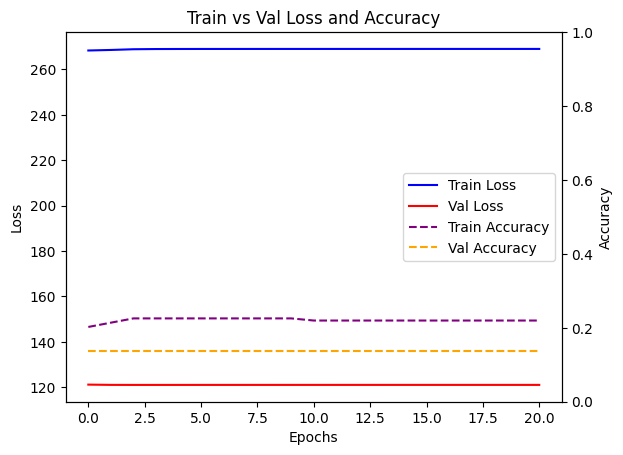

In [19]:
path_gk = 'models/gk/net6_best.pt'
path_val_gk = 'models/gk/net6_val_best.pt'
tbestest = 10000
vbestest = 10000
net6_gk = Net6(True)
num_epochs = 801

if os.path.exists(path_gk):
    checkpoint = torch.load(path_gk, weights_only=True)
    tbestest = checkpoint['loss']
    net6_gk.load_state_dict(checkpoint['model_state_dict'])
 
    
crit = nn.MSELoss()
opt = optim.Adam(net6_gk.parameters(), lr=0.1)    
print('TrainingGoalkeepers', "-"*50)    

plotter(looper(net6_gk, opt, crit, num_epochs, trainload_gk, valload_gk, tbestest, vbestest, path_gk, path_val_gk))


After a few attempts of training the full dataset and just the goalkeepers, it seems that the same model, with 140 inputs instead of 113 is not working well, which means that a different model architecture is most likely needed to better learn the data.

### Training Defenders

Training Forwards --------------------------------------------------
Epoch 0, Time: 2.95sec
Train Loss: 1086.1218, Train Accuracy within 1: 0.0256, Train Accuracy within 5: 0.2275
Valid Loss: 265.3952, Valid Accuracy within 1: 0.0446, Valid Accuracy within 5: 0.3312
Epoch 20, Time: 3.08sec
Train Loss: 236.3916, Train Accuracy within 1: 0.0538, Train Accuracy within 5: 0.2127
Valid Loss: 273.7342, Valid Accuracy within 1: 0.0446, Valid Accuracy within 5: 0.3312
Going nowhere, epoch 22


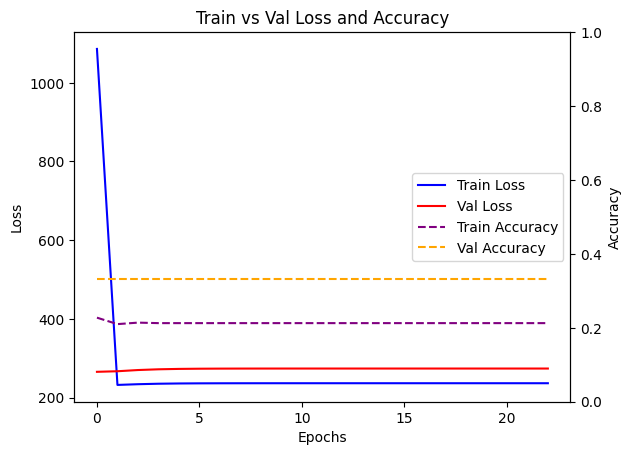

In [16]:
path_df = 'models/df/net6_best.pt'
path_val_df = 'models/df/net6_val_best.pt'
tbestest = 10000
vbestest = 10000
net6_df = Net6()
num_epochs = 801

if os.path.exists('models/df/net6_mf_best.pt'):
    checkpoint = torch.load('models/df/net6_mf_best.pt', weights_only=True)
    tbestest = checkpoint['loss']
    net6_df.load_state_dict(checkpoint['model_state_dict'])
 
    
crit = nn.MSELoss()
opt = optim.Adam(net6_df.parameters(), lr=0.1)    
print('Training Defenders', "-"*50)    

plotter(looper(net6_df, opt, crit, num_epochs, trainload_df, valload_df, tbestest, vbestest, path_df, path_val_df))


The defender dataset also is not being learned either, which is interesting since it only has 113 inputs. 

Below I created a new model architecture for the datasets with 140 inputs. However the data was still not being learned by the model. I decided to try attempts with SGD, ASGD, (not shown because they were worse) and then tried a run with Adamax, which uses the infinity norm. Adamax worked extremely well with the datasets that were not being cooperative before and the datasets were being learned with the same accuracies as the midfielders were before. 

In [8]:
class Net7(nn.Module):
    def __init__(self):
        super(Net7, self).__init__()
        self.relu = nn.ReLU()
        self.layer1 = nn.Linear(140, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer4 = nn.Linear(128, 128)
        self.layer5 = nn.Linear(128, 64)
        self.layer6 = nn.Linear(64, 32)
        self.layer7 = nn.Linear(32, 16)
        self.layer8 = nn.Linear(16, 8)
        self.layer9 = nn.Linear(8, 1)
    
        
    def forward(self,x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer4(x))
        x = self.relu(self.layer5(x))
        x = self.relu(self.layer6(x))
        x = self.relu(self.layer7(x))
        x = self.relu(self.layer8(x))
        return self.layer9(x)

Training Fulls --------------------------------------------------
Epoch 0, Time: 6.90sec
Train Loss: 381.8590, Train Accuracy within 1: 0.1569, Train Accuracy within 5: 0.5322
Valid Loss: 669.4015, Valid Accuracy within 1: 0.0746, Valid Accuracy within 5: 0.2587
Epoch 20, Time: 7.52sec
Train Loss: 220.0200, Train Accuracy within 1: 0.2071, Train Accuracy within 5: 0.6360
Valid Loss: 524.5021, Valid Accuracy within 1: 0.1002, Valid Accuracy within 5: 0.3077
Epoch 40, Time: 7.42sec
Train Loss: 192.9342, Train Accuracy within 1: 0.2978, Train Accuracy within 5: 0.6940
Valid Loss: 624.7406, Valid Accuracy within 1: 0.1002, Valid Accuracy within 5: 0.2424
Epoch 60, Time: 7.28sec
Train Loss: 171.0236, Train Accuracy within 1: 0.3309, Train Accuracy within 5: 0.7193
Valid Loss: 540.1675, Valid Accuracy within 1: 0.0909, Valid Accuracy within 5: 0.2517
Epoch 80, Time: 7.14sec
Train Loss: 149.8092, Train Accuracy within 1: 0.3465, Train Accuracy within 5: 0.7383
Valid Loss: 589.5921, Valid Accu

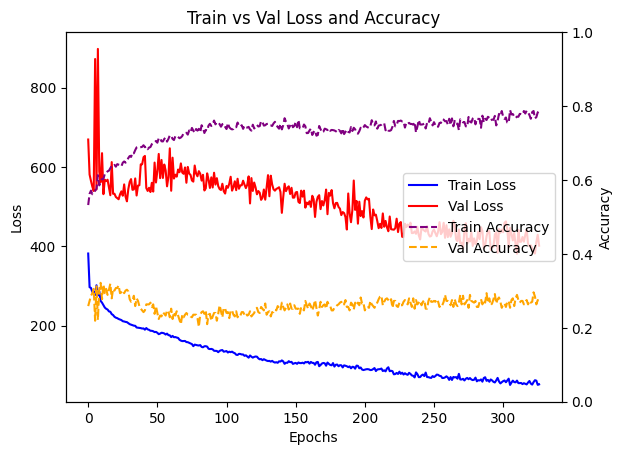

In [25]:
path_full = 'models/full/net7_best.pt'
path_val_full = 'models/full/net7_val_best.pt'
tbestest = 10000
vbestest = 10000
net7_full = Net7()
num_epochs = 801

if os.path.exists(path_full):
    checkpoint = torch.load(path_full, weights_only=True)
    tbestest = checkpoint['loss']
    net7_full.load_state_dict(checkpoint['model_state_dict'])
 
    
crit = nn.MSELoss()
opt = optim.Adamax(net7_full.parameters())    
print('Training Fulls', "-"*50)    

plotter(looper(net7_full, opt, crit, num_epochs, trainload_full, valload_full, tbestest, vbestest, path_full, path_val_full))


Training Fulls --------------------------------------------------
Epoch 0, Time: 2.90sec
Train Loss: 201.4468, Train Accuracy within 1: 0.1238, Train Accuracy within 5: 0.5262
Valid Loss: 289.0630, Valid Accuracy within 1: 0.0446, Valid Accuracy within 5: 0.3185
Epoch 20, Time: 3.09sec
Train Loss: 141.2523, Train Accuracy within 1: 0.1400, Train Accuracy within 5: 0.5962
Valid Loss: 278.1053, Valid Accuracy within 1: 0.0955, Valid Accuracy within 5: 0.3439
Epoch 40, Time: 2.95sec
Train Loss: 127.8666, Train Accuracy within 1: 0.1467, Train Accuracy within 5: 0.5976
Valid Loss: 254.4398, Valid Accuracy within 1: 0.0573, Valid Accuracy within 5: 0.3376
Epoch 60, Time: 3.09sec
Train Loss: 115.5165, Train Accuracy within 1: 0.1803, Train Accuracy within 5: 0.6353
Valid Loss: 267.5607, Valid Accuracy within 1: 0.1019, Valid Accuracy within 5: 0.3057
Epoch 80, Time: 2.98sec
Train Loss: 106.8125, Train Accuracy within 1: 0.2046, Train Accuracy within 5: 0.6366
Valid Loss: 252.3214, Valid Accu

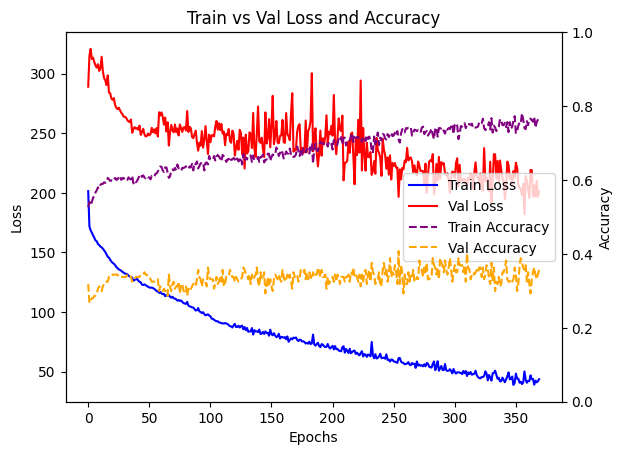

In [29]:
path_df = 'models/df/net6_best.pt'
path_val_df = 'models/df/net6_val_best.pt'
tbestest = 10000
vbestest = 10000
net6_df = Net6()
num_epochs = 801

if os.path.exists(path_df):
    checkpoint = torch.load(path_df, weights_only=True)
    tbestest = checkpoint['loss']
    net6_df.load_state_dict(checkpoint['model_state_dict'])
 
    
crit = nn.MSELoss()
opt = optim.Adamax(net6_df.parameters())    
print('Training Defenders', "-"*50)    

plotter(looper(net6_df, opt, crit, num_epochs, trainload_df, valload_df, tbestest, vbestest, path_df, path_val_df))


The full dataset is learning the full training dataset fairly well, but when predicting the validation dataset, it is doing about 10% worse than the models predicting only one position, which makes sense because there is a lot of variation between positions and what makes a good player in each position. 

Training Goalkeepers --------------------------------------------------
Epoch 0, Time: 0.59sec
Train Loss: 321.8296, Train Accuracy within 1: 0.1908, Train Accuracy within 5: 0.5202
Valid Loss: 95.4521, Valid Accuracy within 1: 0.0690, Valid Accuracy within 5: 0.4138
Epoch 20, Time: 0.66sec
Train Loss: 158.7078, Train Accuracy within 1: 0.1850, Train Accuracy within 5: 0.5896
Valid Loss: 83.2400, Valid Accuracy within 1: 0.1724, Valid Accuracy within 5: 0.4483
Epoch 40, Time: 0.70sec
Train Loss: 144.7827, Train Accuracy within 1: 0.2139, Train Accuracy within 5: 0.6243
Valid Loss: 81.4518, Valid Accuracy within 1: 0.2069, Valid Accuracy within 5: 0.4138
Epoch 60, Time: 0.63sec
Train Loss: 135.7316, Train Accuracy within 1: 0.2370, Train Accuracy within 5: 0.6705
Valid Loss: 79.1143, Valid Accuracy within 1: 0.2414, Valid Accuracy within 5: 0.4138
Epoch 80, Time: 0.62sec
Train Loss: 132.8189, Train Accuracy within 1: 0.2659, Train Accuracy within 5: 0.6705
Valid Loss: 77.0396, Valid Acc

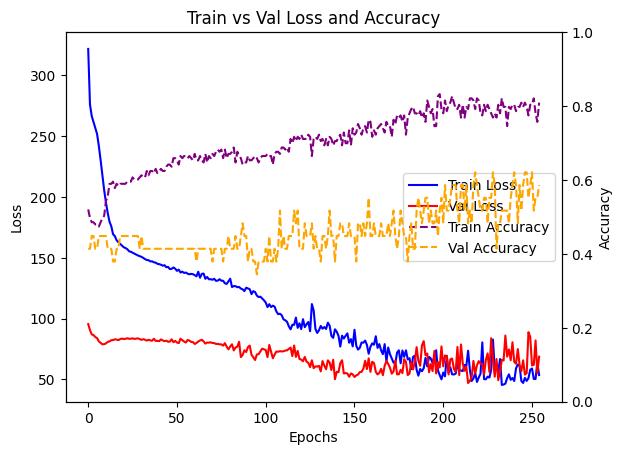

In [30]:
path_gk = 'models/gk/net7_best.pt'
path_val_gk = 'models/gk/net7_val_best.pt'
tbestest = 10000
vbestest = 10000
net7_gk = Net7()
num_epochs = 801

if os.path.exists(path_gk):
    checkpoint = torch.load(path_gk, weights_only=True)
    tbestest = checkpoint['loss']
    net7_gk.load_state_dict(checkpoint['model_state_dict'])
 
    
crit = nn.MSELoss()
opt = optim.Adamax(net7_gk.parameters())    
print('Training Goalkeepers', "-"*50)    

plotter(looper(net7_gk, opt, crit, num_epochs, trainload_gk, valload_gk, tbestest, vbestest, path_gk, path_val_gk))


After learning that Adamax did very well at learning the Defenders and goalkeeper dataset, I want to see if Adamax could be used to increase the accuracies of the midfielder and forward dataset. 

In [28]:
class Net6_11(nn.Module):
    def __init__(self):
        super(Net6_11, self).__init__()
        self.relu = nn.ReLU()
        self.layer1 = nn.Linear(113, 113)
        self.layer2 = nn.Linear(113, 113)
        self.layer3 = nn.Linear(113, 113)
        self.layer4 = nn.Linear(113, 64)
        self.layer5 = nn.Linear(64, 64)
        self.layer6 = nn.Linear(64, 32)
        self.layer7 = nn.Linear(32, 16)
        self.layer8 = nn.Linear(16, 8)
        self.layer9 = nn.Linear(8, 1)
    
        
    def forward(self,x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.relu(self.layer3(x))
        x = self.relu(self.layer4(x))
        x = self.relu(self.layer5(x))
        x = self.relu(self.layer6(x))
        x = self.relu(self.layer7(x))
        x = self.relu(self.layer8(x))
        return self.layer9(x)

Training Midfielders --------------------------------------------------
Epoch 0, Time: 2.33sec
Train Loss: 252.9153, Train Accuracy within 1: 0.1020, Train Accuracy within 5: 0.4544
Valid Loss: 327.2341, Valid Accuracy within 1: 0.0827, Valid Accuracy within 5: 0.3910
Epoch 20, Time: 1.96sec
Train Loss: 235.3594, Train Accuracy within 1: 0.1345, Train Accuracy within 5: 0.4961
Valid Loss: 330.1753, Valid Accuracy within 1: 0.0301, Valid Accuracy within 5: 0.3759
Epoch 40, Time: 1.98sec
Train Loss: 226.6212, Train Accuracy within 1: 0.1406, Train Accuracy within 5: 0.5054
Valid Loss: 329.3274, Valid Accuracy within 1: 0.0526, Valid Accuracy within 5: 0.3985
Epoch 60, Time: 1.80sec
Train Loss: 218.5690, Train Accuracy within 1: 0.1437, Train Accuracy within 5: 0.5085
Valid Loss: 316.5882, Valid Accuracy within 1: 0.0602, Valid Accuracy within 5: 0.3759
Epoch 80, Time: 2.06sec
Train Loss: 209.9663, Train Accuracy within 1: 0.1453, Train Accuracy within 5: 0.5286
Valid Loss: 309.1009, Vali

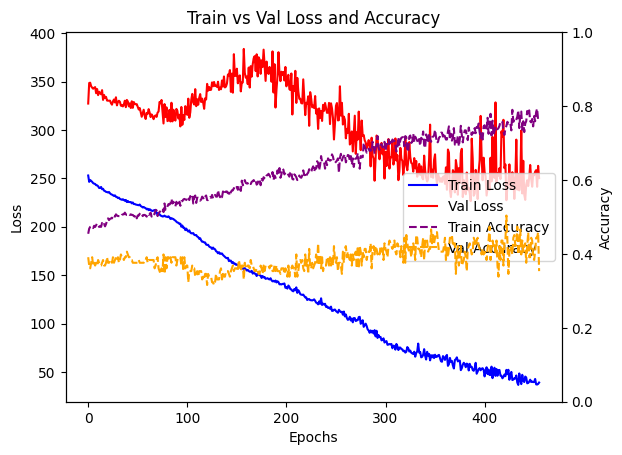

In [30]:
path_mf = 'models/mf/net611_best.pt'
path_val_mf = 'models/mf/net611_val_best.pt'
tbestest = 10000
vbestest = 10000
net6_mf = Net6_11()
num_epochs = 801

if os.path.exists(path_mf):
    checkpoint = torch.load(path_mf, weights_only=True)
    bestest = checkpoint['loss']
    net6_mf.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
opt = optim.Adamax(net6_mf.parameters())    
print('Training Midfielders', "-"*50)    

plotter(looper(net6_mf, opt, crit, num_epochs, trainload_mf, valload_mf, tbestest, vbestest, path_mf, path_val_mf))


Training Midfielders --------------------------------------------------
Epoch 0, Time: 1.84sec
Train Loss: 164.5676, Train Accuracy within 1: 0.1638, Train Accuracy within 5: 0.5750
Valid Loss: 265.0818, Valid Accuracy within 1: 0.0752, Valid Accuracy within 5: 0.4586
Epoch 20, Time: 2.08sec
Train Loss: 47.8990, Train Accuracy within 1: 0.2798, Train Accuracy within 5: 0.7527
Valid Loss: 227.9727, Valid Accuracy within 1: 0.0602, Valid Accuracy within 5: 0.4286
Epoch 40, Time: 1.91sec
Train Loss: 52.3749, Train Accuracy within 1: 0.2628, Train Accuracy within 5: 0.7496
Valid Loss: 218.8707, Valid Accuracy within 1: 0.0977, Valid Accuracy within 5: 0.4511
Epoch 60, Time: 1.83sec
Train Loss: 41.1111, Train Accuracy within 1: 0.2952, Train Accuracy within 5: 0.7434
Valid Loss: 241.4896, Valid Accuracy within 1: 0.0827, Valid Accuracy within 5: 0.3609
Epoch 80, Time: 1.83sec
Train Loss: 38.3289, Train Accuracy within 1: 0.3153, Train Accuracy within 5: 0.7713
Valid Loss: 259.8677, Valid Ac

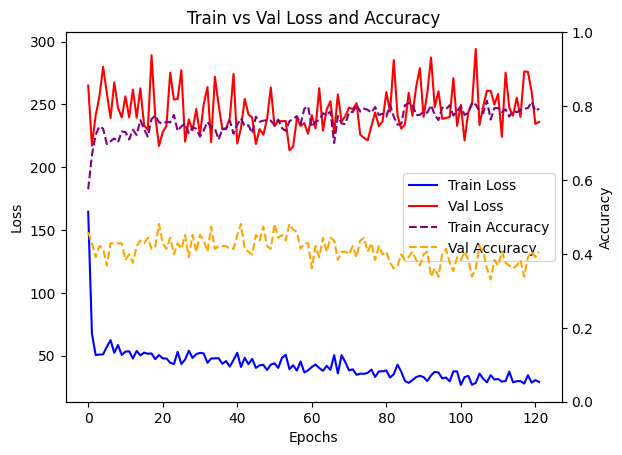

In [67]:
path_mf = 'models/mf/net611_best.pt'
path_val_mf = 'models/mf/net611_val_best.pt'
tbestest = torch.load(path_val_mf, weights_only=True)['loss']
vbestest = 10000
net6_mf = Net6_11()
num_epochs = 801

if os.path.exists(path_val_mf):
    checkpoint = torch.load(path_val_mf, weights_only=True)
    vbestest = checkpoint['loss']
    net6_mf.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
opt = optim.Adamax(net6_mf.parameters())    
print('Training Midfielders', "-"*50)    

plotter(looper(net6_mf, opt, crit, num_epochs, trainload_mf, valload_mf, tbestest, vbestest, path_mf, path_val_mf))


Training Midfielders --------------------------------------------------
Epoch 0, Time: 0.89sec
Train Loss: 603.1955, Train Accuracy within 1: 0.0777, Train Accuracy within 5: 0.3395
Valid Loss: 713.4514, Valid Accuracy within 1: 0.1182, Valid Accuracy within 5: 0.3182
Epoch 20, Time: 1.21sec
Train Loss: 380.9079, Train Accuracy within 1: 0.1063, Train Accuracy within 5: 0.4540
Valid Loss: 611.8693, Valid Accuracy within 1: 0.0636, Valid Accuracy within 5: 0.3273
Epoch 40, Time: 1.01sec
Train Loss: 238.0586, Train Accuracy within 1: 0.1125, Train Accuracy within 5: 0.4826
Valid Loss: 503.1189, Valid Accuracy within 1: 0.0727, Valid Accuracy within 5: 0.2909
Epoch 60, Time: 1.01sec
Train Loss: 186.1933, Train Accuracy within 1: 0.1411, Train Accuracy within 5: 0.5358
Valid Loss: 477.1736, Valid Accuracy within 1: 0.0636, Valid Accuracy within 5: 0.2909
Epoch 80, Time: 0.99sec
Train Loss: 151.4070, Train Accuracy within 1: 0.1554, Train Accuracy within 5: 0.5971
Valid Loss: 420.3372, Vali

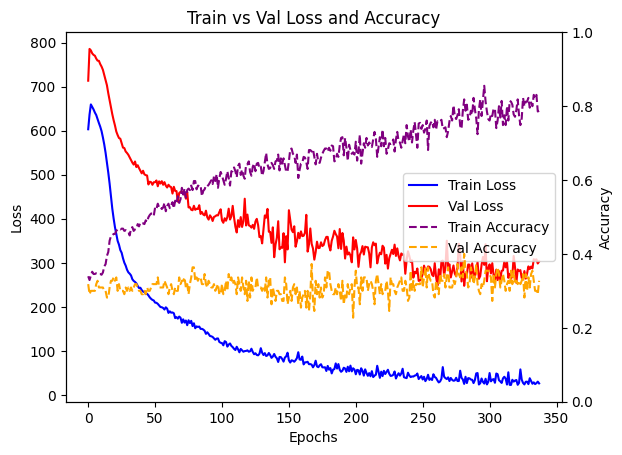

In [86]:
path_fw = 'models/fw/net611_best.pt'
path_val_fw = 'models/fw/net611_val_best.pt'
tbestest = 10000
vbestest = 10000
net6_fw = Net6_11()
num_epochs = 801

if os.path.exists(path_fw):
    checkpoint = torch.load(path_fw, weights_only=True)
    tbestest = checkpoint['loss']
    net6_fw.load_state_dict(checkpoint['model_state_dict'])

crit = nn.MSELoss()
opt = optim.Adamax(net6_fw.parameters())    
print('Training Midfielders', "-"*50)    

plotter(looper(net6_fw, opt, crit, num_epochs, trainload_fw, valload_fw, tbestest, vbestest, path_fw, path_val_fw))


## Testing

In [93]:
def test(model, loader, crit):
    model.eval()
    test_loss = 0
    correct1 = 0
    correct5 = 0
    correct10 = 0
    total = 0
    players = {}
    with torch.no_grad():
        for data, target, name in loader:
            #data = data.view(data.size(0), -1)
            
            outputs = model(data)
            # Calculate loss
            loss = crit(outputs, target.flatten())
            test_loss += loss.item()
            if outputs >= target - 10 and outputs <= target + 10:
                correct10 += 1
                    
                if outputs >= target - 5 and outputs <= target + 5:
                    correct5 += 1
                    
                    if outputs >= target - 1 and outputs <= target + 1:
                        correct1 += 1    
            total += 1

            players[name] = [target, outputs, outputs - target]
    
    avg_loss = test_loss / len(loader)
    accuracy1 = correct1 / total
    acc5 = correct5 / total
    acc10 = correct10 / total
    return avg_loss, accuracy1, acc5, acc10, players

In [108]:
best_fw = "models/fw/net6_best.pt"

fwnet = Net6()
check = torch.load(best_fw, weights_only=True)
fwnet.load_state_dict(check['model_state_dict'])

crit = nn.MSELoss()
fw_loss, a1, a5, a10, players_fw = test(fwnet, test_fw, crit)
print("Forward Dataset")
print(f"Test Loss: {fw_loss:0.4f}\nAccurate within 1: {a1*100:.2f}%\tAccurate within 5: {a5*100:.2f}%\tAccurate within 10: {a10*100:.2f}%")

Forward Dataset
Test Loss: 479.8531
Accurate within 1: 9.62%	Accurate within 5: 36.54%	Accurate within 10: 55.77%


In [109]:
best_fw = "models/fw/net6_val_best.pt"

fwnet = Net6()
check = torch.load(best_fw, weights_only=True)
fwnet.load_state_dict(check['model_state_dict'])

crit = nn.MSELoss()
fw_val_loss, a1, a5, a10, players_val_fw = test(fwnet, test_fw, crit)
print("Forward Dataset")
print(f"Test Loss: {fw_val_loss:0.4f}\nAccurate within 1: {a1*100:.2f}%\tAccurate within 5: {a5*100:.2f}%\tAccurate within 10: {a10*100:.2f}%")

Forward Dataset
Test Loss: 375.4796
Accurate within 1: 10.58%	Accurate within 5: 32.69%	Accurate within 10: 54.81%


In [110]:
best_fw = "models/fw/net611_best.pt"

fwnet = Net6_11()
check = torch.load(best_fw, weights_only=True)
fwnet.load_state_dict(check['model_state_dict'])

crit = nn.MSELoss()
fw_11_loss, a1, a5, a10, players_fw_11 = test(fwnet, test_fw, crit)
print("Forward Dataset")
print(f"Test Loss: {fw_11_loss:0.4f}\nAccurate within 1: {a1*100:.2f}%\tAccurate within 5: {a5*100:.2f}%\tAccurate within 10: {a10*100:.2f}%")

Forward Dataset
Test Loss: 512.0801
Accurate within 1: 4.81%	Accurate within 5: 27.88%	Accurate within 10: 49.04%


In [111]:
best_fw = "models/fw/net611_val_best.pt"

fwnet = Net6_11()
check = torch.load(best_fw, weights_only=True)
fwnet.load_state_dict(check['model_state_dict'])

crit = nn.MSELoss()
fw_11_val_loss, a1, a5, a10, players_val_fw_11 = test(fwnet, test_fw, crit)
print("Forward Dataset")
print(f"Test Loss: {fw_11_val_loss:0.4f}\nAccurate within 1: {a1*100:.2f}%\tAccurate within 5: {a5*100:.2f}%\tAccurate within 10: {a10*100:.2f}%")

Forward Dataset
Test Loss: 523.5346
Accurate within 1: 8.65%	Accurate within 5: 30.77%	Accurate within 10: 50.00%


In [112]:
best_df = "models/df/net6_best.pt"

dfnet = Net6()
check = torch.load(best_df, weights_only=True)
dfnet.load_state_dict(check['model_state_dict'])

crit = nn.MSELoss()
df_loss, a1, a5, a10, players_df = test(dfnet, test_df, crit)
print("Defender Dataset")
print(f"Test Loss: {df_loss:0.4f}\nAccurate within 1: {a1*100:.2f}%\tAccurate within 5: {a5*100:.2f}%\tAccurate within 10: {a10*100:.2f}%")

Defender Dataset
Test Loss: 249.8218
Accurate within 1: 6.21%	Accurate within 5: 33.79%	Accurate within 10: 61.38%


In [113]:
best_df = "models/df/net6_val_best.pt"

dfnet = Net6()
check = torch.load(best_df, weights_only=True)
dfnet.load_state_dict(check['model_state_dict'])

crit = nn.MSELoss()
df_val_loss, a1, a5, a10, players_val_df = test(dfnet, test_df, crit)
print("Defender Dataset")
print(f"Test Loss: {df_val_loss:0.4f}\nAccurate within 1: {a1*100:.2f}%\tAccurate within 5: {a5*100:.2f}%\tAccurate within 10: {a10*100:.2f}%")

Defender Dataset
Test Loss: 237.3038
Accurate within 1: 6.90%	Accurate within 5: 35.17%	Accurate within 10: 62.76%


In [114]:
best_mf = "models/mf/net6_best.pt"

mfnet = Net6()
check = torch.load(best_mf, weights_only=True)
mfnet.load_state_dict(check['model_state_dict'])

crit = nn.MSELoss()
mf_loss, a1, a5, a10, players_mf = test(mfnet, test_mf, crit)
print("Midfielder Dataset")
print(f"Test Loss: {mf_loss:0.4f}\nAccurate within 1: {a1*100:.2f}%\tAccurate within 5: {a5*100:.2f}%\tAccurate within 10: {a10*100:.2f}%")

Midfielder Dataset
Test Loss: 377.4772
Accurate within 1: 8.06%	Accurate within 5: 37.10%	Accurate within 10: 56.45%


In [115]:
best_mf = "models/mf/net6_val_best.pt"

mfnet = Net6()
check = torch.load(best_mf, weights_only=True)
mfnet.load_state_dict(check['model_state_dict'])

crit = nn.MSELoss()
mf_val_loss, a1, a5, a10, players_val_mf = test(mfnet, test_mf, crit)
print("Midfielder Dataset")
print(f"Test Loss: {mf_val_loss:0.4f}\nAccurate within 1: {a1*100:.2f}%\tAccurate within 5: {a5*100:.2f}%\tAccurate within 10: {a10*100:.2f}%")

Midfielder Dataset
Test Loss: 338.6668
Accurate within 1: 7.26%	Accurate within 5: 29.03%	Accurate within 10: 55.65%


In [116]:
best_mf = "models/mf/net611_best.pt"

mfnet = Net6_11()
check = torch.load(best_mf, weights_only=True)
mfnet.load_state_dict(check['model_state_dict'])

crit = nn.MSELoss()
mf_11_loss, a1, a5, a10, players_mf_11 = test(mfnet, test_mf, crit)
print("Midfielder Dataset")
print(f"Test Loss: {mf_11_loss:0.4f}\nAccurate within 1: {a1*100:.2f}%\tAccurate within 5: {a5*100:.2f}%\tAccurate within 10: {a10*100:.2f}%")

Midfielder Dataset
Test Loss: 394.6788
Accurate within 1: 4.03%	Accurate within 5: 25.00%	Accurate within 10: 48.39%


In [117]:
best_mf = "models/mf/net611_val_best.pt"

mfnet = Net6_11()
check = torch.load(best_mf, weights_only=True)
mfnet.load_state_dict(check['model_state_dict'])

crit = nn.MSELoss()
mf_11_val_loss, a1, a5, a10, players_mf_11_val = test(mfnet, test_mf, crit)
print("Midfielder Dataset")
print(f"Test Loss: {mf_11_val_loss:0.4f}\nAccurate within 1: {a1*100:.2f}%\tAccurate within 5: {a5*100:.2f}%\tAccurate within 10: {a10*100:.2f}%")

Midfielder Dataset
Test Loss: 351.2080
Accurate within 1: 5.65%	Accurate within 5: 32.26%	Accurate within 10: 50.81%


In [118]:
best_gk = "models/gk/net7_best.pt"

gknet = Net7()
check = torch.load(best_gk, weights_only=True)
gknet.load_state_dict(check['model_state_dict'])

crit = nn.MSELoss()
gk_loss, a1, a5, a10, players_gk = test(gknet, test_gk, crit)
print("Goalkeeper Dataset")
print(f"Test Loss: {gk_loss:0.4f}\nAccurate within 1: {a1*100:.2f}%\tAccurate within 5: {a5*100:.2f}%\tAccurate within 10: {a10*100:.2f}%")

Goalkeeper Dataset
Test Loss: 97.8102
Accurate within 1: 11.76%	Accurate within 5: 47.06%	Accurate within 10: 70.59%


In [119]:
best_gk = "models/gk/net7_val_best.pt"

gknet = Net7()
check = torch.load(best_gk, weights_only=True)
gknet.load_state_dict(check['model_state_dict'])

crit = nn.MSELoss()
gk_val_loss, a1, a5, a10, players_val_gk = test(gknet, test_gk, crit)
print("Goalkeeper Dataset")
print(f"Test Loss: {gk_val_loss:0.4f}\nAccurate within 1: {a1*100:.2f}%\tAccurate within 5: {a5*100:.2f}%\tAccurate within 10: {a10*100:.2f}%")

Goalkeeper Dataset
Test Loss: 71.6859
Accurate within 1: 8.82%	Accurate within 5: 47.06%	Accurate within 10: 67.65%


## Analysis

Since I saved my best models for test loss and validation loss, I want to do an ensemble with weighted averages based on the average test loss of each model. The smaller the test loss, the higher weighted that value should be. 

In [141]:
fw_losses = [fw_loss, fw_val_loss, fw_11_loss, fw_11_val_loss]
fw_total = sum(fw_losses)
for i in range(len(fw_losses)):
    fw_losses[i] = fw_total / fw_losses[i]
fw_sum = sum(fw_losses)
for i in range(len(fw_losses)):
    fw_losses[i] = fw_losses[i] / fw_sum 

    
mf_losses = [mf_loss, mf_val_loss, mf_11_loss, mf_11_val_loss]
mf_total = sum(mf_losses)
for i in range(len(mf_losses)):
    mf_losses[i] = mf_total / mf_losses[i]
mf_sum = sum(mf_losses)
for i in range(len(mf_losses)):
    mf_losses[i] = mf_losses[i] / mf_sum 

    
df_losses = [df_loss, df_val_loss]
df_total = sum(df_losses)
for i in range(len(df_losses)):
    df_losses[i] = df_total / df_losses[i]
df_sum = sum(df_losses)
for i in range(len(df_losses)):
    df_losses[i] = df_losses[i] / df_sum 

    
gk_losses = [gk_loss, gk_val_loss]
gk_total = sum(gk_losses)
for i in range(len(gk_losses)):
    gk_losses[i] = gk_total / gk_losses[i]
gk_sum = sum(gk_losses)
for i in range(len(gk_losses)):
    gk_losses[i] = gk_losses[i] / gk_sum 


In [170]:
fw_outs = [players_fw, players_val_fw, players_fw_11, players_val_fw_11]

fw_avgs = {}

for player in players_fw:
    avg_val = 0
    for i in range(len(fw_outs)):
        avg_val += fw_outs[i][player][1] * fw_losses[i]
    fw_avgs[player] = float(avg_val), float(players_fw[player][0]), float(avg_val - players_fw[player][0])
    

mf_outs = [players_mf, players_val_mf, players_mf_11, players_mf_11_val]

mf_avgs = {}

for player in players_mf:
    avg_val = 0
    for i in range(len(mf_outs)):
        avg_val += mf_outs[i][player][1] * mf_losses[i]
    mf_avgs[player] = float(avg_val), float(players_mf[player][0]), float(avg_val - players_mf[player][0])
    
    
df_outs = [players_df, players_val_df]

df_avgs = {}

for player in players_df:
    avg_val = 0
    for i in range(len(df_outs)):
        avg_val += df_outs[i][player][1] * df_losses[i]
    df_avgs[player] = float(avg_val), float(players_df[player][0]), float(avg_val - players_df[player][0])

    
gk_outs = [players_gk, players_val_gk]

gk_avgs = {}

for player in players_gk:
    avg_val = 0
    for i in range(len(gk_outs)):
        avg_val += gk_outs[i][player][1] * gk_losses[i]
    gk_avgs[player] = float(avg_val), float(players_gk[player][0]), float(avg_val - players_gk[player][0])
    



In [204]:
total_players = [fw_avgs, mf_avgs, df_avgs, gk_avgs]
over_25 = []
for data in total_players:
    for player in data:
        if abs(data[player][2]) > 24.9:
            over_25.append((player, data[player][0],data[player][1],data[player][2]))
        #print(data[player])

In [218]:
def difSort(x):
    return x[3]

over_25.sort(reverse=True,key=difSort)
for thing in over_25:
    print(f"Player: {thing[0]}\nPredicted Value: {thing[1]:07.4f}\tActual Value: {thing[2]:0.1f}\tDifference: {thing[3]:0.4f}")

Player: Pascal Gro?
Predicted Value: 56.8884	Actual Value: 8.0	Difference: 48.8884
Player: James Maddison
Predicted Value: 110.9305	Actual Value: 70.0	Difference: 40.9305
Player: Jeremy Doku
Predicted Value: 104.3316	Actual Value: 65.0	Difference: 39.3316
Player: Willian
Predicted Value: 39.3990	Actual Value: 3.0	Difference: 36.3990
Player: Mohamed Salah
Predicted Value: 87.7328	Actual Value: 55.0	Difference: 32.7328
Player: Thiago Silva
Predicted Value: 32.0491	Actual Value: 0.2	Difference: 31.8491
Player: Simon Adingra
Predicted Value: 57.5527	Actual Value: 30.0	Difference: 27.5527
Player: Adam Lallana
Predicted Value: 28.1305	Actual Value: 1.0	Difference: 27.1305
Player: Tom Cairney
Predicted Value: 28.5478	Actual Value: 2.0	Difference: 26.5478
Player: Reece James
Predicted Value: 14.9193	Actual Value: 40.0	Difference: -25.0807
Player: Nayef Aguerd
Predicted Value: 09.2542	Actual Value: 35.0	Difference: -25.7458
Player: Rayan A?t-Nouri
Predicted Value: 09.2008	Actual Value: 35.0	Dif

Above is the list of players that had values the model predicted "incorrectly" by over 25 (million euros). Most of the players were predicted lower than their market value, some fairly, others unfairly, and some because certain player's market values are extremely influenced by the intangible factors that go into a market value.

## Positive Difference Players

The models predicted that these 9 players' market values were 25 million euros or more than the market values they were given. For all of these players, it was because they had an amazing 23/24 season, which the models correctly identified

#### Pascal Groß
Pascal Groß had a very good season, ending with 4 goals and 10 assists. He was 4th in the league in Shot-Creating Actions (SCAs) which tracks passes, tackles, etc. that lead to his team taking a shot on the opponent's goal, and 19th in Goal-Creating Actions (GCAs), which is the same statistic, only if the shot scored a goal (which is mainly up to his teammates). He ranked 3rd highest in the league (2nd highest midfielder) in passes completed and tied 3rd for the most assists in the season as well. Another very important statistic was key passes, passes that lead to a shot, and he was second in the league, as well as 2nd for passes into the opponent's third of the field as well.

There are a few more passing statistics where he was top 3 in the league. All of this is showing that he was an integral central midfielder for his team throughout the season. He was given a market value of 8 million, mainly because he is 32 years old. For most soccer players, their prime is normally in the ages of 26-28. Groß being 32 is past his prime, and teams do not want to pick up players that are past their prime because they only have a few playing seasons left, and are more likely to have injuries. 

Over the summer he was sold for 7 million euros to a German team (his home country) and is playing decently well, but there is not enough data to tell whether or not he is having a good season.


#### Thiago Silva
Thiago Silva has been in professional soccer leagues since 2003 (before I was even born), which is a testament to how long he has played the game. In the 23/24 season he was 38 years old, which is very much past the prime of normal players, but defenders normally do play longer than forwards or midfielders because they run a significant amount less throughout a game on average. But he is nearing the end of his career and because of that, his market value is 1 million euros. However the model predicted him at 32 million euros, which is an extremely large difference.

He was in the top 10 for times clearing the ball out of the box but also tied for 6th in most errors leading to a goal. For passing he was 10th in total completed passes, bit first in passing percentage (completed passes / passes attempted) with a whopping 94%. He had the 16th most touches on the ball throughout the season, but was only dispossed once, which is the second best for any non-goalkeeper that had over 500 touches on the ball. He did have three goals, which is very good for a defender, but other than that his stats were near the middle of the league. 

He was most likely given a 32 million euro price tag by the model because over all he had a season that was similar to what a 32 million euro player had in the training dataset.

#### James Maddison
James Maddison, 26 during the 23/24 season, played a season worth a 110 million euro player, while he had a 70 million euro market value. It was his first season at a new team, which got him for 46 million euros, which was, in retrospect, one of the best deals of the summer. (Note that the team he came from got relegated {dropped from the league} so he had a slightly discounted transfer value because of that.) To get a top player, which has performed well season after season, that is coming into his prime years was extremely smart by the team which got him. And he is already paying off.

He was tied 12th for most assists (9), 7th in SCA (161), and 2nd highest in SCA per 90 minutes played. He played just under 24 complete games in a 38 game season, and if he had played only 10 more games (the same amount as the player in first in this category) at the same rate per 90 minute game he would have the most in the league. He tied 10th for GCAs, and 8th in progressive passes (passes forward essentialy). Ranking high in all of these statistics as a midfielder is very good for your market value, and the model seems to agree with that as well. 


#### Others
Jeremy Doku and Simon Adingra are two young players who had a breakout season in 23/24. Their values were predicted similarly to James Maddison's. The models predicted them to be worth 39 million and 27.5 million more respectively. This was Jeremy Doku's first Premier League season as he was bought for 60 million euros (when his market value was 24 million) and he immediately proved to be a great player. he was first in dribbles forward into the opponent's box, and 7th in receiving passes in advanced positons. Simon Adingra also played his first season in the Premier League as well and he played brilliantly (actually one of my favorite players to watch) and the model agrees. He is very good at dribbling the ball forward and recieving passes in forward positoins, which was reflected in his stats for the season as well, placing 15th and 10th in the league, respectively.  

Mohamed Salah (31), Willian (34), Tom Cairney (32), and Adam Lallana (35) are the remaining players that were predicted much higher than their given market values and for similar reasons to Pascal Groß and Thiago Silva... because they are "old". All of these players had very strong seasons (Mohamed Salah especially, 18 goals and 10 assists) and were extremely important to their teams. Despite this, their age causes them to be valued lower by the football community because once again, you're more likely to get injuried and you're past your prime (Mohamed Salah certainly isn't though).


## Negatively Predicted Players



### Inflation in the market
There are a lot of players that got under predicted by their models by a large amount. A large group of them are defenders, that I believe the models incorrectly predicted. Ruben Diaz, Josko Gvardiol, Ben White, Gabriel M., Trent Alexander-Arnold, and some others are all some of the best defenders in the league and the model is predicting all of them to be much lower than their market value. The cause of this is inflation in prices of players.

In the 2019/20 season only 18 defenders were thought to be worth 30 million euros or more. In the 2023/24 season that number has jumped to 40 defenders. Not to take anything away from the players because of how hard they worked to get where they are but the prices of some of these defenders are not justified. This leads to the top players being worth even more, which causes a big inflation in the average price for a top defender, such as the ones listed above. The models, not knowing this inflation has happened, predict that the defenders are worth what a top defender would be in previous seasons, not in the current economy, which is why a lot of defenders are being predicted incorrectly by around 30-35 million euros.


### Insufficient playing time

Players such as Sandro Tonali, Christopher Nkunku, Ian Maatsen, Cheick Doucoure, and Reece James all were predicted extremely low values compared to their given market values. This is because these players played a few games (Less than 5 for most of them) throughout the season. Whether it was because they were banned from playing (Tonali for betting) or had injuries (Reece James, who has played in 52 of a possible 114 games through three seasons because of injury), these players did not have a significant enough amount of minutes for the models to get anywhere close to what their given market value is. But since the values should be based on how a player does throughout a season, I wouldn't necessarily consider these predictions to be incorrect. All of these players are relatively young and have a lot of potential to develop into great players, which is why their market values are set relatively high, but after a season of almost no game time, there is no way to tell if that is actually still the case.


### Future Potential
The four players with the most difference in their given market values and predicted market values from the models are in their own group. These players are all young talents that are amazing players, and because of this they have high values based on how well they play, but they also are given an increased sum because they are still young and have the chance to develop into even better players. This is why their given market values exceed 100 million euros. Bukayo Saka, Phil Foden, and Erling Haaland are  in the top 10 predicted market values throughout the entire dataset, so their great seasons were seen by the models and they were given very fair values. 

Declan Rice however, was predicted to have a value of 35 milion instead of 120 million euros. He was a top 15 player throughout the season in a few stats such as balls intercepted, progressive passes, tackles, touches on the ball, and combined for 15 goals and assists throughout the season. Funnily enough his team had a net 1.21 more goals per 90 minutes when he was off the field compared to when he was playing. Other than that, he had a good season, but nothing too spectacular, which I believe is why the model predicted 35 million, which is still a relatively decent number all things considered.

### Players that actually had a poor season

Bruno Fernandes, Lucas Paqueta, Alexis Mac Allister, and Douglas Luiz are all very good players and for the most part deserve the market value they've been given. All of these players had a standout 22/23 season, which prompted them to have a high market value, but in the 23/24 season they didn't replicate nearly the same numbers as they did in the previous season. This should prompt their values to drop by some number. Bruno Fernandes' dropped by 5, Douglas Luiz' increased by 30, Mac Allister's increased by 5, and Paqueta's increased by 20. Despite the massive spikes in price for the two players, their statistics throughout the season were decent and better than most other players, but not nearly good enough to keep the values they garnered from the season before.

#### Rasmus Højlund

Rasmus at 20 years old was brought into the Premier Leauge as an exciting young player, even after having a mediocore previous season in Itay. And because of this excitement and buzz about how good of a player he could be come, his market value jumped by 20 million from the start of the 23/24 season to the end of the 23/24 season. However, he did not live up to his expectations at all. He scored 10 goals in 24 games, which is decent, but there were players who scored the same amount of goals in 10 games less and players that doubled his goal tally in the same amount of time as him. As a forward, scoring goals/helping your team score goals is the most important job, and he did not do that well enough, or much else that season, which is why the models predicted him at 17 million, a whopping 47.5 million less than his given market value.

#### Bernardo Silva

As much as I love Bernardo Silva, he isn't worth his 70 million euro market value anymore. He had a decent 23/24 season with 6 goals, tied for 12th in assists with 9, and 15th best in SCAs. But other than that, he did average compared to his midfield rivals. He recieved the ball in advanced positions 12th most in the leauge, but when he got them, most of the time he just passed the ball backwards and not much came of it which hurt statistics such as progressive passes. He's still a very good player and the model sees that by predicting him just shy of 37 million euros, about half of his given market value. 


### Unsure why the models predicted as they did 

Mohammed Kudus came into the Premier League in the 23/24 season after transfering for 40 million euros. Looking at his statistics he had a very good debut season, which surprised me when the model predicted him at 9 million euros, when his given market value is 50 million. He is very good at taking on a player 1 on 1 and dribbling past them, utilizing his quick feet and speed. It shows too, because he attempted the most dribbles past a defender (221 times, second place was 169 times), and successfully got past the defender 124 of those times. He was in the top 20 for progressive passes received, times dribbled forward, GCAs, number of loose balls recovered, and tackles which one his team possession of the ball (2nd best for forwards). The rest of his stats, specifically passing, were not standout and below average for the most part, which is what the models  seem to have picked up on, leading to his lower predicted value. He is the only player here where I would say the stats of the player do not agree with the output of the model (other than the inflation adjusted players).

## Conclusion

After strenious analysis of the largest differences in market value and the models' predict values, I can definitely see where and why the model got certain outputs. Using Deep Learning this way, with this analysis, can lead football teams to start looking for possible undervalued players. By stripping away any biases that players could have and seeing how well they did based on statistics solely, teams can get a good starting point of which players they should look at getting. Then they can factor in their own biases, or other intangibles such as being injury prone, or not fitting the team dynamic. 